<a href="https://colab.research.google.com/github/bulut19/supply-chain-network-analysis/blob/main/supply_chain_network_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NetworkX for Inventory Network Analysis

## Section 1: Tutorial on Sensitivity Analysis in Multi-Echelon Inventory Systems

### Introduction

In supply chain analytics, we frequently model systems as **networks**: collections
of locations (nodes) connected by shipping routes (edges). For example, a
manufacturer ships product to distribution centers, which in turn replenish
regional stores. Understanding how inventory flows through such a network and
how sensitive that flow is to disruptions or parameter changes is a central
problem in inventory management.

**NetworkX** is a Python package for creating, analyzing, and visualizing complex
networks. It provides tools to:
- Build directed and undirected graphs with node/edge attributes
- Compute shortest paths, maximum flow, and minimum-cost flow
- Identify bottleneck nodes and edges
- Visualize network structures

In this tutorial, we use NetworkX to model multi-echelon inventory systems,
optimize replenishment flows, and perform **sensitivity analysis**, where we ask how
the optimal solution changes when parameters like capacity, demand, or lead time
change. This connects directly to the shadow price / dual variable concepts from
linear programming, and to the scenario analysis approach used in classic multi-echelon inventory case studies like ALKO.

**Reference:** NetworkX documentation: https://networkx.org/documentation/stable/

**Installation**

NetworkX is not part of the standard Colab environment, so we install it first.
We also import the supporting packages used throughout this tutorial.

In [ ]:
!pip install networkx --quiet

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

print(f"NetworkX version: {nx.__version__}")

NetworkX version: 3.6.1


### 1.1 Graphs, Nodes, and Edges

A **graph** G = (V, E) consists of:
- A set of **nodes** V: locations in the supply network such as suppliers, warehouses, and stores
- A set of **edges** E: directed shipping routes between those locations

In inventory networks, edges are **directed** (product flows one way), from supplier toward customer. NetworkX represents this with a `DiGraph` (directed graph) object.

The key functions introduced here are:
- `nx.DiGraph()` — create an empty directed graph
- `G.add_node(name, **attrs)` — add a node with inventory attributes
- `G.add_edge(u, v, **attrs)` — add a directed edge from u to v
- `G.nodes(data=True)` — view all nodes and their attributes
- `G.edges(data=True)` — view all edges and their attributes

**Documentation:** https://networkx.org/documentation/stable/reference/classes/digraph.html


**AI Prompt:**
*"Write Python code using NetworkX to create a directed graph representing a 3-node supply chain: Supplier, Warehouse, and Store. Each node should have attributes for mean daily demand and holding cost per unit per day. Each edge should have attributes for transport cost per unit, capacity in units per day, and lead time in days. Print all nodes and edges with their attributes."*

In [ ]:
# Create an empty directed graph
supply_chain = nx.DiGraph()

# Add nodes: each represents a supply chain location
# mean_demand: average daily demand (units/day)
# holding_cost: cost to hold one unit per day ($/unit/day)
supply_chain.add_node('Supplier',  role='source',        mean_demand=0,  holding_cost=0.05)
supply_chain.add_node('Warehouse', role='intermediate',  mean_demand=20, holding_cost=0.10)
supply_chain.add_node('Store',     role='sink',          mean_demand=20, holding_cost=0.15)

# Add directed edges: each represents a shipping route
# transport_cost: cost to ship one unit ($/unit)
# capacity: maximum units shippable per day
# ead_time: days from order placement to delivery
supply_chain.add_edge('Supplier',  'Warehouse', transport_cost=0.09, capacity=100, lead_time=5)
supply_chain.add_edge('Warehouse', 'Store',     transport_cost=0.10, capacity=50,  lead_time=2)

print("Nodes and their attributes:")
for node, attrs in supply_chain.nodes(data=True):
    print(f"  {node}: {attrs}")

print("\nEdges and their attributes:")
for u, v, attrs in supply_chain.edges(data=True):
    print(f"  {u} --> {v}: {attrs}")

Nodes and their attributes:
  Supplier: {'role': 'source', 'mean_demand': 0, 'holding_cost': 0.05}
  Warehouse: {'role': 'intermediate', 'mean_demand': 20, 'holding_cost': 0.1}
  Store: {'role': 'sink', 'mean_demand': 20, 'holding_cost': 0.15}

Edges and their attributes:
  Supplier --> Warehouse: {'transport_cost': 0.09, 'capacity': 100, 'lead_time': 5}
  Warehouse --> Store: {'transport_cost': 0.1, 'capacity': 50, 'lead_time': 2}


### 1.2 Visualizing the Network

NetworkX integrates with matplotlib to draw graphs. For supply chain networks we arrange nodes left-to-right to reflect the direction of product flow. We use `nx.draw_networkx()` with a manually specified layout, and `nx.draw_networkx_edge_labels()` to annotate edges with cost and capacity information.

**Documentation:** https://networkx.org/documentation/stable/reference/drawing.html

**AI Prompt:**
*"Using NetworkX and matplotlib, draw the directed supply chain graph just created. Arrange nodes left to right as Supplier, Warehouse, Store. Color nodes green, gold, and red respectively. Label each edge with its transport cost and capacity. Add a title and remove the axis border."*

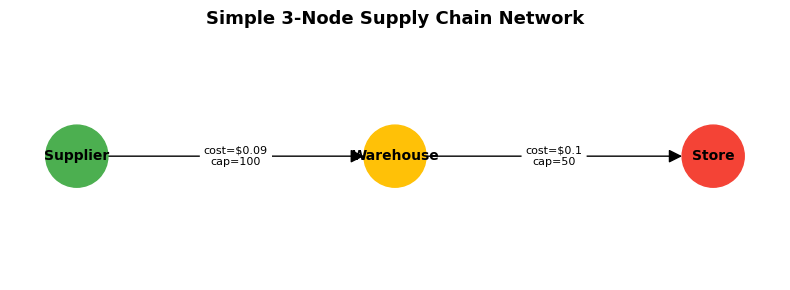

In [ ]:
# Node positions arranged left-to-right to reflect product flow direction
node_positions = {
    'Supplier':  (0, 0),
    'Warehouse': (1, 0),
    'Store':     (2, 0)
}

node_colors = ['#4CAF50', '#FFC107', '#F44336']  # green, gold, red

fig, ax = plt.subplots(figsize=(8, 3))

nx.draw_networkx(
    supply_chain,
    pos=node_positions,
    node_color=node_colors,
    node_size=2000,
    font_size=10,
    font_weight='bold',
    arrows=True,
    arrowsize=20,
    ax=ax
)

edge_labels = {
    (u, v): f"cost=${d['transport_cost']}\ncap={d['capacity']}"
    for u, v, d in supply_chain.edges(data=True)
}
nx.draw_networkx_edge_labels(supply_chain, pos=node_positions,
                              edge_labels=edge_labels, font_size=8, ax=ax)

ax.set_title("Simple 3-Node Supply Chain Network", fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

### 1.3 Summary

In this section we built our first inventory network in NetworkX:
- **Nodes** represent supply chain locations carrying inventory attributes such as demand and holding cost
- **Directed edges** represent shipping routes carrying economic parameters such as transport cost, capacity, and lead time
- The `DiGraph` object stores the full network and makes it easy to query, modify, and visualize

In the next section, we scale this up to a realistic multi-echelon network modeled after the ALKO case, and compute inventory policy parameters — EOQ, safety stock, and ROP, directly from the graph's node and edge attributes.

## Section 2: Modeling a Multi-Echelon Inventory Network




### 2.1 The ALKO Network

We now build a realistic supply chain network based on the ALKO case, a classic two-echelon distribution scenario from Chopra & Meindl's *Supply Chain Management*.

ALKO's current distribution system consists of:
- **1 production facility** in Cleveland
- **5 regional distribution centers** (West, North, Southwest, Southeast, East)
- Each DC independently serves its regional customers

This is a classic **two-echelon inventory network**: plant replenishes DCs,
DCs serve customers. In NetworkX, each location becomes a node and each
shipping lane becomes a directed edge.

The inventory policy parameters used throughout are taken directly from the
ALKO case:
- Review period: $T = 6$ days
- Replenishment lead time: $L = 5$ days
- Cycle service level: $\text{CSL} = 0.95$
- Holding cost: $h = \$0.15$ per unit per day
- TL inbound transport cost (plant → DC): $t_r^{in} = \$0.09$ per unit
- LTL outbound transport cost (DC → customer): $t_r^{out} = \$0.10$ per unit

Regions are assigned to one of three demand tiers: DC_West is High ($\mu_D$ = 12, $\sigma_D$ = 4), DC_North and DC_Southwest are Medium ($\mu_D$ ​=8, $\sigma_D$ ​=3 ), and DC_Southeast and DC_East are Low ($\mu_D$ = 5, $\sigma_D$ ​= 2). We model a single product for simplicity, the network structure and formulas are identical across product types.

**AI Prompt:**
*"Using NetworkX, build a directed graph for the ALKO supply chain: one Plant
node connected to five DC nodes (West, North, Southwest, Southeast, East).
Each DC node should store attributes for product type, mean daily demand, and
demand standard deviation. Each edge should store inbound transport cost and
lead time. Print all nodes and edges with their attributes."*

In [ ]:
# Inventory policy parameters from the ALKO case
T   = 6      # review period (days)
L   = 5      # replenishment lead time (days)
CSL = 0.95   # cycle service level
h   = 0.15   # holding cost ($/unit/day)
tr_in  = 0.09  # TL inbound transport cost, plant -> DC ($/unit)
tr_out = 0.10  # LTL outbound transport cost, DC -> customer ($/unit)

# Create directed graph
alko_network = nx.DiGraph()

# Add the Cleveland plant node (source — no demand, just supply)
alko_network.add_node('Plant_Cleveland',
                       role='plant',
                       mean_demand=0,
                       demand_std=0)

# Add the five regional DC nodes
# mean_demand: average daily demand per region (units/day)
# demand_std:  standard deviation of daily demand per region (units/day)
dc_demand = {
    'DC_West':      {'tier': 'High',   'mean_demand': 12.0, 'demand_std': 4.0},
    'DC_North':     {'tier': 'Medium', 'mean_demand': 8.0,  'demand_std': 3.0},
    'DC_Southwest': {'tier': 'Medium', 'mean_demand': 8.0,  'demand_std': 3.0},
    'DC_Southeast': {'tier': 'Low',    'mean_demand': 5.0,  'demand_std': 2.0},
    'DC_East':      {'tier': 'Low',    'mean_demand': 5.0,  'demand_std': 2.0},
}

for dc_name, demand_attrs in dc_demand.items():
    alko_network.add_node(dc_name,
                          role='distribution_center',
                          **demand_attrs)

# Add directed edges from Plant to each DC
# All inbound routes share the same transport cost and lead time (ALKO case)
for dc_name in dc_demand.keys():
    alko_network.add_edge('Plant_Cleveland', dc_name,
                          transport_cost=tr_in,
                          lead_time=L)

# Display structure
print("Nodes:")
for node, attrs in alko_network.nodes(data=True):
    print(f"  {node}: {attrs}")

print("\nEdges:")
for u, v, attrs in alko_network.edges(data=True):
    print(f"  {u} --> {v}: {attrs}")

Nodes:
  Plant_Cleveland: {'role': 'plant', 'mean_demand': 0, 'demand_std': 0}
  DC_West: {'role': 'distribution_center', 'tier': 'High', 'mean_demand': 12.0, 'demand_std': 4.0}
  DC_North: {'role': 'distribution_center', 'tier': 'Medium', 'mean_demand': 8.0, 'demand_std': 3.0}
  DC_Southwest: {'role': 'distribution_center', 'tier': 'Medium', 'mean_demand': 8.0, 'demand_std': 3.0}
  DC_Southeast: {'role': 'distribution_center', 'tier': 'Low', 'mean_demand': 5.0, 'demand_std': 2.0}
  DC_East: {'role': 'distribution_center', 'tier': 'Low', 'mean_demand': 5.0, 'demand_std': 2.0}

Edges:
  Plant_Cleveland --> DC_West: {'transport_cost': 0.09, 'lead_time': 5}
  Plant_Cleveland --> DC_North: {'transport_cost': 0.09, 'lead_time': 5}
  Plant_Cleveland --> DC_Southwest: {'transport_cost': 0.09, 'lead_time': 5}
  Plant_Cleveland --> DC_Southeast: {'transport_cost': 0.09, 'lead_time': 5}
  Plant_Cleveland --> DC_East: {'transport_cost': 0.09, 'lead_time': 5}


### 2.2 Visualizing the ALKO Network

The ALKO network has a **star topology**: one central plant connected to five
regional DCs. We use a hub-and-spoke layout to make this structure clear.

**AI Prompt:**
*"Draw the ALKO NetworkX graph using a hub-and-spoke layout: place the plant
node at the center and arrange the five DC nodes evenly around it in a circle. Color the plant node blue and DC nodes orange. Label each edge with its transport cost."*

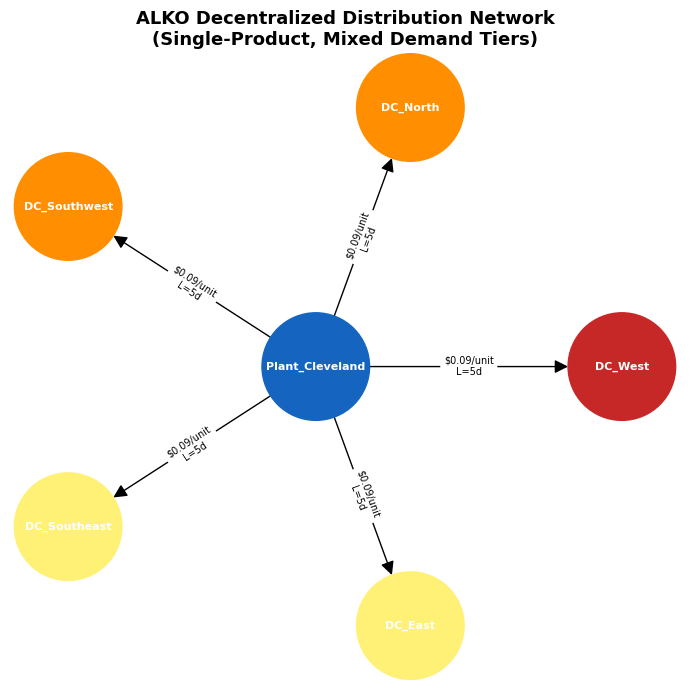

In [ ]:
# Hub-and-spoke layout: plant at center, DCs arranged in a circle around it
dc_nodes = list(dc_demand.keys())
n_dcs = len(dc_nodes)

# Compute evenly spaced angles for the five DC nodes
angles = [2 * np.pi * i / n_dcs for i in range(n_dcs)]
radius = 2.0

node_positions = {'Plant_Cleveland': (0, 0)}
for dc_name, angle in zip(dc_nodes, angles):
    node_positions[dc_name] = (radius * np.cos(angle), radius * np.sin(angle))

# Color plant blue, DCs by demand tier (red=High, orange=Medium, yellow=Low)
tier_colors = {'High': '#C62828', 'Medium': '#FF8F00', 'Low': '#FFF176'}
node_colors = []
for node in alko_network.nodes():
    if node == 'Plant_Cleveland':
        node_colors.append('#1565C0')
    else:
        tier = alko_network.nodes[node]['tier']
        node_colors.append(tier_colors[tier])

fig, ax = plt.subplots(figsize=(7, 7))

nx.draw_networkx(
    alko_network,
    pos=node_positions,
    node_color=node_colors,
    node_size=6000,
    font_size=8,
    font_weight='bold',
    font_color='white',
    arrows=True,
    arrowsize=20,
    ax=ax
)

edge_labels = {
    (u, v): f"${d['transport_cost']}/unit\nL={d['lead_time']}d"
    for u, v, d in alko_network.edges(data=True)
}
nx.draw_networkx_edge_labels(alko_network, pos=node_positions,
                              edge_labels=edge_labels, font_size=7, ax=ax)

ax.set_title("ALKO Decentralized Distribution Network\n(Single-Product, Mixed Demand Tiers)",
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

### 2.3 Computing Inventory Policy Parameters on the Graph

One of the key advantages of representing the supply chain as a NetworkX graph is that we can compute inventory parameters **directly from node and edge attributes** and store the results back on the graph. This avoids maintaining separate spreadsheets and keeps all information in one place.

Following the ALKO case, for each DC node we compute:

**Batch size** (order quantity based on review period):
$$Q = T \cdot \mu_D$$

**Cycle inventory** (average stock on hand during a review cycle):
$$\text{Cycle} = \frac{Q}{2} = \frac{T \cdot \mu_D}{2}$$

**Standard deviation of demand over review plus lead time** $T + L$:
$$\sigma_{T+L} = \sqrt{T + L} \cdot \sigma_D$$

**Safety stock** (buffer stock to meet the CSL target):
$$SS = F_S^{-1}(\text{CSL}) \cdot \sigma_{T+L}$$

where $F_S^{-1}$ is the inverse standard normal CDF (the $z$-score).

**Reorder point**:
$$\text{ROP} = (T + L) \cdot \mu_D + SS$$

**Expected total annual cost per product** at a single DC:
$$\text{ETAC} = 365 \times \left[ (SS + \text{Cycle}) \cdot h + \mu_D \cdot t_r \right]$$

where $t_r = t_r^{in} + t_r^{out} = \$0.19$/unit is the total unit transportation
cost (inbound TL + outbound LTL), as defined in the ALKO case.

These are the same formulas from the Inventory exercises (worksheet 'Normal')
and the ALKO case Question 1 solution. Here we implement them in Python and
store each result as a new node attribute in the graph.

**AI Prompt:**
*"For each DC node in my NetworkX ALKO graph, compute the following inventory
parameters using the node's mean_demand and demand_std attributes: batch size Q, cycle inventory, sigma over T+L, safety stock at 95% CSL, reorder point, and expected total annual cost. Store each result back as a node attribute and display a summary table using pandas."*

In [ ]:
# Compute ROP policy parameters for each DC node.
# All parameters stored directly back on the graph nodes

tr_total = tr_in + tr_out   # total unit transport cost ($/unit), ALKO case
z = stats.norm.ppf(CSL)     # z-score for CSL = 0.95 --> z ≈ 1.645

for dc_name in dc_demand.keys():
    mu    = alko_network.nodes[dc_name]['mean_demand']   # units/day
    sigma = alko_network.nodes[dc_name]['demand_std']    # units/day

    # Batch size and cycle inventory
    batch_size    = T * mu
    cycle_inv     = batch_size / 2

    # Demand variability over the combined review + lead time window
    sigma_TL = np.sqrt(T + L) * sigma

    # Safety stock and reorder point
    safety_stock = z * sigma_TL
    rop          = (T + L) * mu + safety_stock

    # Expected total annual cost at this DC (one product)
    etac = 365 * ((safety_stock + cycle_inv) * h + mu * tr_total)

    # Store all results back as node attributes
    alko_network.nodes[dc_name]['batch_size']    = round(batch_size, 2)
    alko_network.nodes[dc_name]['cycle_inv']     = round(cycle_inv, 2)
    alko_network.nodes[dc_name]['sigma_TL']      = round(sigma_TL, 2)
    alko_network.nodes[dc_name]['safety_stock']  = round(safety_stock, 2)
    alko_network.nodes[dc_name]['rop']           = round(rop, 2)
    alko_network.nodes[dc_name]['etac']          = round(etac, 2)

# Display results as a summary table
rows = []
for dc_name in dc_demand.keys():
    attrs = alko_network.nodes[dc_name]
    rows.append({
    'Tier':         attrs['tier'],
    'DC':           dc_name,
    'Q (units)':    attrs['batch_size'],
    'Cycle Inv':    attrs['cycle_inv'],
    'Sigma T+L':    attrs['sigma_TL'],
    'Safety Stock': attrs['safety_stock'],
    'ROP':          attrs['rop'],
    'ETAC ($/yr)':  attrs['etac']
})

results_df = pd.DataFrame(rows).set_index('DC')
print(f"z-score for CSL={CSL}: {z:.4f}\n")
print(results_df.to_string())

z-score for CSL=0.95: 1.6449

                Tier  Q (units)  Cycle Inv  Sigma T+L  Safety Stock     ROP  ETAC ($/yr)
DC                                                                                      
DC_West         High       72.0       36.0      13.27         21.82  153.82      3997.92
DC_North      Medium       48.0       24.0       9.95         16.37  104.37      2764.84
DC_Southwest  Medium       48.0       24.0       9.95         16.37  104.37      2764.84
DC_Southeast     Low       30.0       15.0       6.63         10.91   65.91      1765.36
DC_East          Low       30.0       15.0       6.63         10.91   65.91      1765.36


### 2.4 Summary

In this section we:
- Built the ALKO two-echelon distribution network as a NetworkX directed graph
- Assigned inventory-relevant attributes (demand, cost) to nodes and edges
- Computed EOQ batch size, cycle inventory, safety stock, ROP, and total annual cost for each DC node directly from graph attributes
- Stored all results back on the graph, keeping the entire model self-contained

Because all five DC nodes share the same demand parameters in the decentralized system, their inventory policy values are identical, confirming the ALKO case setup. In Section 4, we will vary these parameters systematically across nodes to perform sensitivity analysis.

In the next section, we use NetworkX's built-in flow algorithms to solve a
replenishment routing problem on this network, connecting to the classic transportation and transshipment linear programming problem.

## Section 3: Flow Optimization on the Inventory Network

### 3.1 From Transportation LP to Network Flow

Transportation and transshipment problems are a classic application of
linear programming. The core structure of those problems is:
- Each **source** node has a supply capacity
- Each **sink** node has a demand requirement
- Each **arc** has a shipping cost and possibly a capacity constraint
- We minimize total shipping cost subject to supply, demand, and capacity constraints

This is exactly a **minimum-cost flow problem**, and NetworkX has a built-in
solver for it: `nx.min_cost_flow()`. Rather than setting up a PuLP model
manually, we encode the supply/demand and cost information directly as node
and edge attributes on the graph, and NetworkX handles the rest.

The minimum-cost flow problem on a directed graph G = (V, E) is:

$$\min_{f} \sum_{(i,j) \in E} c_{ij} \cdot f_{ij}$$

subject to:

$$\sum_{j:(i,j)\in E} f_{ij} - \sum_{j:(j,i)\in E} f_{ji} = b_i \quad \forall i \in V$$

$$0 \leq f_{ij} \leq u_{ij} \quad \forall (i,j) \in E$$

where:
- $f_{ij}$ is the flow (units shipped) on arc $(i,j)$
- $c_{ij}$ is the cost per unit shipped on arc $(i,j)$
- $b_i$ is the **net supply** at node $i$: positive if the node is a supplier,
  negative if it is a customer (demand node), and zero if it is a transshipment node
- $u_{ij}$ is the capacity of arc $(i,j)$

The flow conservation constraint (the first constraint) says that at every node,
the total flow out minus the total flow in equals the net supply. This is the
network equivalent of the supply and demand balance constraints from a
standard transportation linear program.

**Documentation:** https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.flow.min_cost_flow.html

### 3.2 Setting Up the Flow Problem

We now build a replenishment routing problem for the ALKO network. The plant
must ship enough product to cover each DC's order quantity Q for one review
period. This mirrors the classic transportation and transshipment linear programming problem.

NetworkX's `min_cost_flow()` requires two specific attributes on the graph:
- **Node attribute** `'demand'`: net demand at the node. Negative means the
  node is a supplier (it pushes flow out), positive means it is a consumer
  (it pulls flow in). This is the $b_i$ value in the formulation above.
- **Edge attribute** `'weight'`: cost per unit of flow on that arc ($c_{ij}$)
- **Edge attribute** `'capacity'`: maximum flow on that arc ($u_{ij}$)

Note: NetworkX uses the convention that $b_i < 0$ means supply and
$b_i > 0$ means demand, the opposite of what you might expect. Keep this
in mind when reading the code.

**AI Prompt:**
*"Build a NetworkX min-cost flow problem for the ALKO supply chain. The plant
node supplies the total of all DC order quantities. Each DC node demands exactly its batch size Q. Set the node demand attribute to negative at the plant and positive at each DC. Set edge weight to transport cost and edge capacity to a large number. Solve with nx.min_cost_flow() and print the flow on each arc."*

In [ ]:
# Copy the ALKO graph so we do not overwrite Section 2 attributes
flow_network = alko_network.copy()

# Compute total supply needed at the plant: sum of all DC batch sizes
total_supply = sum(
    flow_network.nodes[dc]['batch_size'] for dc in dc_demand.keys()
)

# Assign node 'demand' attribute (required by nx.min_cost_flow)
# Plant supplies the total: negative demand = net supplier
flow_network.nodes['Plant_Cleveland']['demand'] = -total_supply

# Each DC demands exactly its batch size Q
for dc_name in dc_demand.keys():
    q = flow_network.nodes[dc_name]['batch_size']
    flow_network.nodes[dc_name]['demand'] = q

# Assign edge attributes required by nx.min_cost_flow:
# 'weight'   = cost per unit shipped (c_ij)
# 'capacity' = max units per shipment (u_ij)
# We use a capacity of 200 units per arc — realistic for a single
# truck load in a lighting fixture distribution context.
for u, v in flow_network.edges():
    flow_network[u][v]['weight']   = flow_network[u][v]['transport_cost']
    flow_network[u][v]['capacity'] = 200

# Tighten DC_West arc to create a binding constraint
flow_network['Plant_Cleveland']['DC_West']['capacity'] = 80

# Solve the minimum-cost flow problem
# Returns a dict of dicts: flow_dict[u][v] = units shipped on arc (u,v)
flow_solution = nx.min_cost_flow(flow_network)

# Display results
print("Optimal Replenishment Flow (units shipped per arc):\n")
total_cost = 0
for u in flow_solution:
    for v, flow in flow_solution[u].items():
        if flow > 0:
            cost_per_unit = flow_network[u][v]['transport_cost']
            arc_cost = flow * cost_per_unit
            total_cost += arc_cost
            print(f"  {u} --> {v}: {flow:.1f} units  |  "
                  f"cost = {flow:.1f} x ${cost_per_unit} = ${arc_cost:.2f}")

print(f"\nTotal replenishment cost (one review period): ${total_cost:.2f}")

Optimal Replenishment Flow (units shipped per arc):

  Plant_Cleveland --> DC_West: 72.0 units  |  cost = 72.0 x $0.09 = $6.48
  Plant_Cleveland --> DC_North: 48.0 units  |  cost = 48.0 x $0.09 = $4.32
  Plant_Cleveland --> DC_Southwest: 48.0 units  |  cost = 48.0 x $0.09 = $4.32
  Plant_Cleveland --> DC_Southeast: 30.0 units  |  cost = 30.0 x $0.09 = $2.70
  Plant_Cleveland --> DC_East: 30.0 units  |  cost = 30.0 x $0.09 = $2.70

Total replenishment cost (one review period): $20.52


### 3.3 Visualizing the Optimal Flow

We now draw the network with arc widths proportional to the flow on each edge, making it easy to see where product is being shipped.

**AI Prompt:**
*"Draw the ALKO NetworkX graph using the same hub-and-spoke layout as before.
Scale each edge width proportionally to the flow on that arc from the
min_cost_flow solution. Label each edge with the flow quantity. Use the same
node colors as before."*

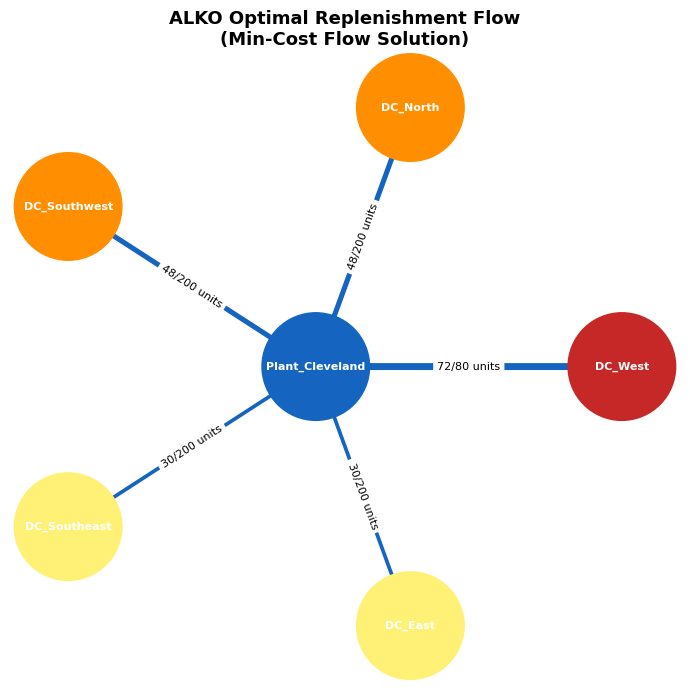

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

# Collect flow values for edge width scaling
edge_flows = [flow_solution[u][v] for u, v in flow_network.edges()]
max_flow   = max(edge_flows) if max(edge_flows) > 0 else 1
edge_widths = [1 + 4 * (f / max_flow) for f in edge_flows]

# Draw base network
nx.draw_networkx_nodes(flow_network, pos=node_positions,
                       node_color=node_colors, node_size=6000, ax=ax)
nx.draw_networkx_labels(flow_network, pos=node_positions,
                        font_size=8, font_weight='bold',
                        font_color='white', ax=ax)
nx.draw_networkx_edges(flow_network, pos=node_positions,
                       width=edge_widths, arrows=True,
                       arrowsize=20, edge_color='#1565C0', ax=ax)

# Label edges with flow quantity
flow_labels = {
    (u, v): f"{flow_solution[u][v]:.0f}/{flow_network[u][v]['capacity']} units"
    for u, v in flow_network.edges()
    if flow_solution[u][v] > 0
}
nx.draw_networkx_edge_labels(flow_network, pos=node_positions,
                              edge_labels=flow_labels, font_size=8, ax=ax)

ax.set_title("ALKO Optimal Replenishment Flow\n(Min-Cost Flow Solution)",
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

### 3.4 Connection to the Transportation LP

The min-cost flow solution above is equivalent to solving the following linear program, the classic transportation problem:

$$\min_{f} \sum_{(i,j) \in E} c_{ij} \cdot f_{ij}$$

$$\text{s.t.} \quad \sum_{j} f_{ij} = S_i \quad \forall i \in \{\text{plant}\}$$

$$\sum_{i} f_{ij} = Q_j \quad \forall j \in \{\text{DCs}\}$$

$$0 \leq f_{ij} \leq u_{ij} \quad \forall (i,j) \in E$$

where $S_i$ is the plant supply and $Q_j$ is the batch size at DC $j$.

With differentiated demand across regions, the solver ships different quantities to each DC. The DC_West arc operates at the highest utilization given its tighter capacity, foreshadowing the bottleneck analysis in Section 4.

### 3.5 Summary

In this section we:
- Formulated a replenishment routing problem as a minimum-cost flow problem
- Solved it using `nx.min_cost_flow()`, the NetworkX equivalent of the
  classic Transportation LP
- Visualized the optimal flows with edge widths proportional to shipment volume
- Connected the flow conservation constraints to the supply/demand balance
  constraints of the Transportation LP

In the next section, we perform **sensitivity
analysis** by systematically varying arc capacities, demand levels, and
demand correlation, and tracking how the optimal cost and safety stock respond.

## Section 4: Sensitivity Analysis on the Inventory Network

### 4.1 What is Sensitivity Analysis in a Network Context?


In linear programming, sensitivity analysis asks if we change how does the optimal objective value change when a constraint's right-hand side changes? For example, if a warehouse gets one extra unit of storage capacity, how much money does that save us? Some constraints are expensive so relaxing them would significantly reduce cost. Others are not currently limiting us at all, so changing them has no effect. Sensitivity analysis helps us tell the difference.

In a network flow model, we ask the same question but on a graph: which arc capacity is most costly to the system? Which node's demand is driving up safety stock the most? We answer these by solving the problem repeatedly across a range of parameter values and watching how the cost responds.

In LP sensitivity analysis, the shadow price of a constraint tells you how much the objective changes per unit of relaxation. Here we compute the same thing empirically where we solve the min-cost flow problem repeatedly across a range of parameter values and observe how total cost responds.

This section has three parts:
1. **Capacity sensitivity**: vary one arc's capacity and track total cost
2. **Demand sensitivity**: vary mean demand and track safety stock and ROP
3. **Correlation sensitivity**: vary inter-regional demand correlation ρ
   and track centralized safety stock (ALKO case scenario)

### 4.2 Sensitivity to Arc Capacity

We first ask: what happens to the total replenishment cost if the capacity
of the arc from the plant to one specific DC is progressively reduced?

When a capacity constraint becomes **binding**, the system can no longer ship the full batch size Q to that DC in one period. This forces either partial fulfillment or cost increases elsewhere.

We vary the capacity of the Plant -> DC_West arc from 200 (unconstrained)
down to 10 units, solve the min-cost flow at each value, and record the
total replenishment cost. When the capacity falls below Q = 72 units (DC_West's batch size under the High-demand tier), the problem becomes infeasible.

**AI Prompt :**
*"Using the flow_network graph and dc_demand dictionary already defined above, write a sensitivity analysis loop that varies the capacity of the
Plant_Cleveland to DC_West edge from 200 down to 10 in steps of 5. At each
value, try to solve nx.min_cost_flow() and record total cost. If infeasible, record NaN. Plot total cost vs capacity with a vertical dashed line at the DC_West batch size."*

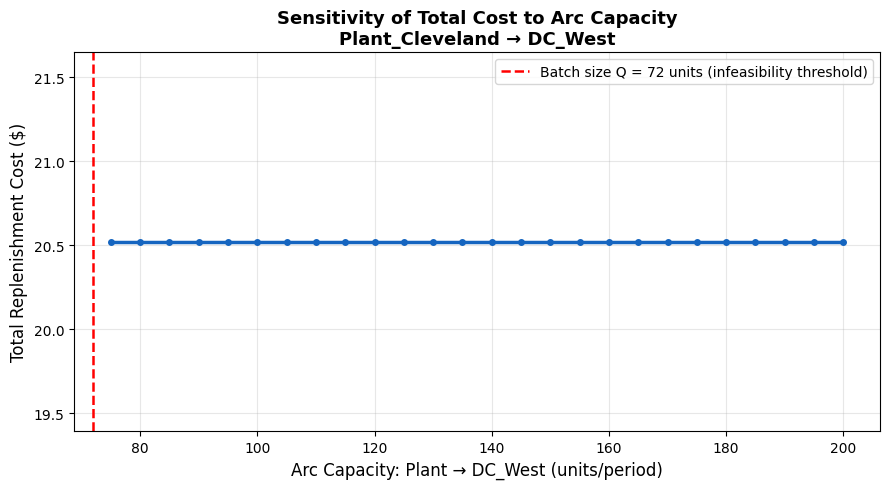

Minimum feasible capacity:  75 units
Cost at minimum feasible capacity: $20.52
Cost at full capacity (200 units): $20.52
Approximate shadow price near threshold: $0.0000 per unit of capacity


In [ ]:
# Capacity sensitivity analysis: Plant_Cleveland --> DC_West arc.

capacity_values = list(range(200, 5, -5))
total_costs     = []
batch_size_west = alko_network.nodes['DC_West']['batch_size']  # = 72 units (High-demand tier)

for cap in capacity_values:
    # Work on a fresh copy so we do not corrupt the base network
    test_network = flow_network.copy()
    test_network['Plant_Cleveland']['DC_West']['capacity'] = cap

    try:
        sol = nx.min_cost_flow(test_network)
        cost = sum(
            sol[u][v] * test_network[u][v]['transport_cost']
            for u in sol for v in sol[u]
            if sol[u][v] > 0
        )
        total_costs.append(cost)
    except nx.NetworkXUnfeasible:
        # Capacity too low to meet DC_West demand — infeasible
        total_costs.append(np.nan)

# Plot the sensitivity curve
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(capacity_values, total_costs,
        color='#1565C0', linewidth=2.5, marker='o', markersize=4)

# Mark the batch size threshold — below this the problem becomes infeasible
ax.axvline(x=batch_size_west, color='red', linestyle='--', linewidth=1.8,
           label=f'Batch size Q = {batch_size_west:.0f} units (infeasibility threshold)')

ax.set_xlabel("Arc Capacity: Plant → DC_West (units/period)", fontsize=12)
ax.set_ylabel("Total Replenishment Cost ($)", fontsize=12)
ax.set_title("Sensitivity of Total Cost to Arc Capacity\n"
             "Plant_Cleveland → DC_West", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find the capacity level at which cost first starts rising
feasible_costs  = [(c, v) for c, v in zip(capacity_values, total_costs)
                   if not np.isnan(v)]
binding_cap     = min(feasible_costs, key=lambda x: x[0])
print(f"Minimum feasible capacity:  {binding_cap[0]} units")
print(f"Cost at minimum feasible capacity: ${binding_cap[1]:.2f}")
print(f"Cost at full capacity (200 units): ${feasible_costs[0][1]:.2f}")

feasible_df = pd.DataFrame({'cap': capacity_values, 'cost': total_costs}).dropna()
feasible_df = feasible_df.sort_values('cap').reset_index(drop=True)
delta_cost  = feasible_df['cost'].diff()
delta_cap   = feasible_df['cap'].diff()
shadow_approx = (delta_cost / delta_cap).dropna().iloc[-1]
print(f"Approximate shadow price near threshold: ${abs(shadow_approx):.4f} per unit of capacity")

The shadow price of $0.0000 reflects that in a star topology there are no alternative routing paths where capacity reductions do not increase cost, so they simply push the system toward infeasibility.

### 4.3 Identifying Bottleneck Arcs

A **bottleneck arc** is one whose capacity constraint is binding at the
optimum where reducing its capacity further would immediately increase cost or make the problem infeasible. We identify bottleneck arcs by comparing the optimal flow on each arc to its capacity. An arc is a bottleneck when:

$$f_{ij}^* = u_{ij}$$

that is, the optimal flow equals the arc capacity. We compute a
**utilization ratio** for each arc:

$$\text{Utilization}_{ij} = \frac{f_{ij}^*}{u_{ij}} \in [0, 1]$$

An arc with utilization = 1.0 is fully saturated and is a bottleneck.
We visualize utilization as edge color intensity on the network diagram.

**AI Prompt:**
*"Using the flow_network and flow_solution already defined above, compute the utilization ratio (flow / capacity) for every arc. Store utilization as an edge attribute. Draw the network using the same node_positions and node_colors as before, with edge colors scaled from light to dark red by utilization value. Print a table of arc, flow, capacity, and utilization sorted highest to lowest."*

Arc Utilization (sorted by bottleneck severity):

                           Arc  Flow  Capacity  Utilization
     Plant_Cleveland → DC_West  72.0        80         0.90
    Plant_Cleveland → DC_North  48.0       200         0.24
Plant_Cleveland → DC_Southwest  48.0       200         0.24
Plant_Cleveland → DC_Southeast  30.0       200         0.15
     Plant_Cleveland → DC_East  30.0       200         0.15


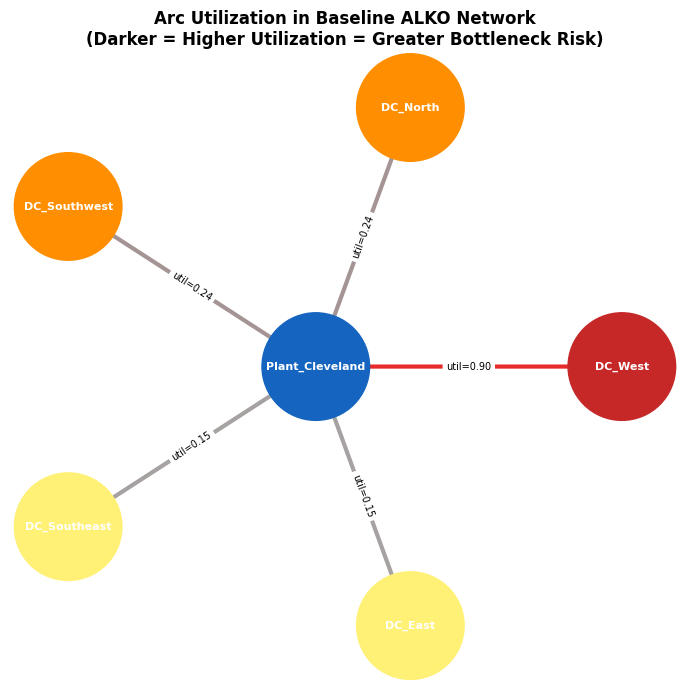

In [ ]:
# Compute and visualize arc utilization in the baseline solution
# Utilization = optimal flow / capacity
# Arcs at utilization = 1.0 are bottlenecks

# Store utilization on each edge
utilization_data = []
for u, v in flow_network.edges():
    f   = flow_solution[u][v]
    cap = flow_network[u][v]['capacity']
    util = f / cap if cap > 0 else 0
    flow_network[u][v]['utilization'] = util
    utilization_data.append({
        'Arc':         f"{u} → {v}",
        'Flow':        round(f, 1),
        'Capacity':    cap,
        'Utilization': round(util, 3)
    })

# Print utilization table sorted highest to lowest
util_df = pd.DataFrame(utilization_data).sort_values('Utilization',
                                                       ascending=False)
print("Arc Utilization (sorted by bottleneck severity):\n")
print(util_df.to_string(index=False))

# Visualize: edge color intensity proportional to utilization
utilizations  = [flow_network[u][v]['utilization']
                 for u, v in flow_network.edges()]
edge_colors = [(util, 0.1, 0.1, 0.3 + 0.7 * util)
               for util in utilizations]

fig, ax = plt.subplots(figsize=(7, 7))

nx.draw_networkx_nodes(flow_network, pos=node_positions,
                       node_color=node_colors, node_size=6000, ax=ax)
nx.draw_networkx_labels(flow_network, pos=node_positions,
                        font_size=8, font_weight='bold',
                        font_color='white', ax=ax)
nx.draw_networkx_edges(flow_network, pos=node_positions,
                       edge_color=edge_colors, width=3,
                       arrows=True, arrowsize=20, ax=ax)

util_labels = {
    (u, v): f"util={flow_network[u][v]['utilization']:.2f}"
    for u, v in flow_network.edges()
}
nx.draw_networkx_edge_labels(flow_network, pos=node_positions,
                              edge_labels=util_labels,
                              font_size=7, ax=ax)

ax.set_title("Arc Utilization in Baseline ALKO Network\n"
             "(Darker = Higher Utilization = Greater Bottleneck Risk)",
             fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

### 4.4 Sensitivity to Demand: Safety Stock and ROP

We now shift from flow cost to inventory cost. A key question often is: *how does the required safety stock change as demand
variability increases?*

From the ROP policy formula:

$$SS = F_S^{-1}(\text{CSL}) \cdot \sigma_{T+L} = z \cdot \sqrt{T+L} \cdot \sigma_D$$

Safety stock grows **linearly** with $\sigma_D$. This means a DC facing
more volatile demand must carry proportionally more buffer stock, at a
direct cost of $SS \times h$ per day.

We perform sensitivity analysis by varying $\sigma_D$ from 0.5 to 6.0
units/day across all DC nodes and tracking how safety stock, ROP, and
total annual cost respond. This is the parametric equivalent of the classic newsvendor/ROP result that
increasing $\sigma$ raises the required order quantity.

**AI Prompt:**
*"Using the parameters T, L, h, tr_total, and z already defined above, write a sensitivity loop that varies sigma_D from 0.5 to 6.0 in steps of 0.5 while holding mu_D fixed at 8 units/day. At each value recompute safety stock, ROP, and ETAC using the same formulas as in Section 2. Plot three subplots: safety stock vs sigma, ROP vs sigma, and ETAC vs sigma. Print a summary table."*

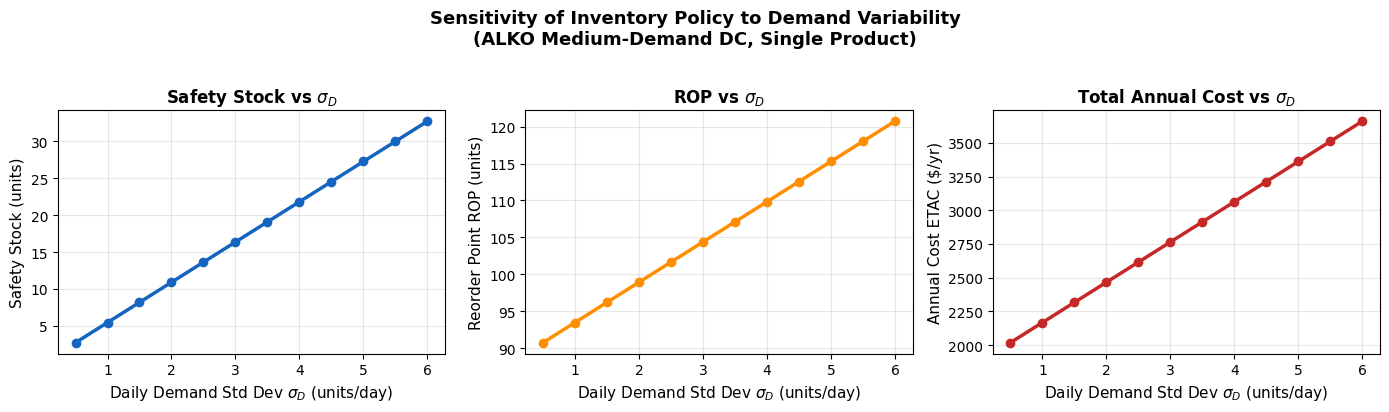

 sigma_D  Safety Stock    ROP  ETAC ($/yr)
     0.5          2.73  90.73      2018.14
     1.0          5.46  93.46      2167.48
     1.5          8.18  96.18      2316.82
     2.0         10.91  98.91      2466.16
     2.5         13.64 101.64      2615.50
     3.0         16.37 104.37      2764.84
     3.5         19.09 107.09      2914.18
     4.0         21.82 109.82      3063.52
     4.5         24.55 112.55      3212.86
     5.0         27.28 115.28      3362.21
     5.5         30.00 118.00      3511.55
     6.0         32.73 120.73      3660.89


In [ ]:
# Sensitivity of safety stock, ROP, and ETAC to demand variability

sigma_values  = np.arange(0.5, 6.5, 0.5)
mu_fixed = 8.0   # Medium-tier mean demand held constant while sigma varies

ss_results   = []
rop_results  = []
etac_results = []

for sigma in sigma_values:
    sigma_TL     = np.sqrt(T + L) * sigma
    safety_stock = z * sigma_TL
    batch_size   = T * mu_fixed
    cycle_inv    = batch_size / 2
    rop          = (T + L) * mu_fixed + safety_stock
    etac         = 365 * ((safety_stock + cycle_inv) * h + mu_fixed * tr_total)

    ss_results.append(safety_stock)
    rop_results.append(rop)
    etac_results.append(etac)

# Plot three sensitivity curves
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(sigma_values, ss_results, color='#1565C0',
             linewidth=2.5, marker='o')
axes[0].set_xlabel("Daily Demand Std Dev $\\sigma_D$ (units/day)", fontsize=11)
axes[0].set_ylabel("Safety Stock (units)", fontsize=11)
axes[0].set_title("Safety Stock vs $\\sigma_D$", fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(sigma_values, rop_results, color='#FF8F00',
             linewidth=2.5, marker='o')
axes[1].set_xlabel("Daily Demand Std Dev $\\sigma_D$ (units/day)", fontsize=11)
axes[1].set_ylabel("Reorder Point ROP (units)", fontsize=11)
axes[1].set_title("ROP vs $\\sigma_D$", fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(sigma_values, etac_results, color='#C62828',
             linewidth=2.5, marker='o')
axes[2].set_xlabel("Daily Demand Std Dev $\\sigma_D$ (units/day)", fontsize=11)
axes[2].set_ylabel("Annual Cost ETAC ($/yr)", fontsize=11)
axes[2].set_title("Total Annual Cost vs $\\sigma_D$", fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle("Sensitivity of Inventory Policy to Demand Variability\n"
             "(ALKO Medium-Demand DC, Single Product)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary table
sens_df = pd.DataFrame({
    'sigma_D':      sigma_values,
    'Safety Stock': np.round(ss_results, 2),
    'ROP':          np.round(rop_results, 2),
    'ETAC ($/yr)':  np.round(etac_results, 2)
})
print(sens_df.to_string(index=False))

These use the same ROP policy formulas, with CSL = 0.95

### 4.5 Sensitivity to Demand Correlation: Centralization vs Decentralization

This subsection directly mirrors **ALKO Case Question 4**: how does the
recommendation to centralize inventory change as inter-regional demand
correlation $\rho$ changes?

In the centralized system, all five regions are served by a single National
Distribution Center (NDC). The key advantage of centralization is **risk
pooling**: when demand across regions is independent ($\rho = 0$), the
variance of total demand grows more slowly than in the decentralized case,
reducing the required safety stock.

The variance of centralized demand across $K = 5$ regions is (ALKO case):

$$\text{Var}(D^C) = \sum_{k=1}^{5} \sigma_k^2 + 2\rho \sum_{i > j} \sigma_i \sigma_j$$

The centralized standard deviation is $\sigma^C_D = \sqrt{\text{Var}(D^C)}$,
and the centralized safety stock is:

$$SS^C = z \cdot \sqrt{T + L} \cdot \sigma^C_D$$

We compare this to the total decentralized safety stock:

$$SS^{dec} = 5 \times z \cdot \sqrt{T + L} \cdot \sigma_D$$

As $\rho \to 1$ (perfectly correlated demand), centralization provides
no risk pooling benefit and $SS^C \to SS^{dec}$. As $\rho \to 0$, the
benefit of centralization is greatest. We encode both systems as NetworkX
graphs and sweep $\rho$ from 0 to 1 to visualize this tradeoff directly
on the network.

**AI Prompt:**
*"Using T, L, z, and sigma_D already defined above, write a sensitivity loop
that varies rho from 0 to 1 in steps of 0.05. At each rho compute the total
decentralized safety stock as 5 times the single-DC safety stock, and the
centralized safety stock using the pooled variance formula: K times sigma_D
squared plus 2 times rho times the number of region pairs times sigma_D
squared, where K=5. Plot both on the same graph with a shaded region showing
the difference. Print a summary at rho = 0, 0.25, 0.5, 0.75, 1.0."*

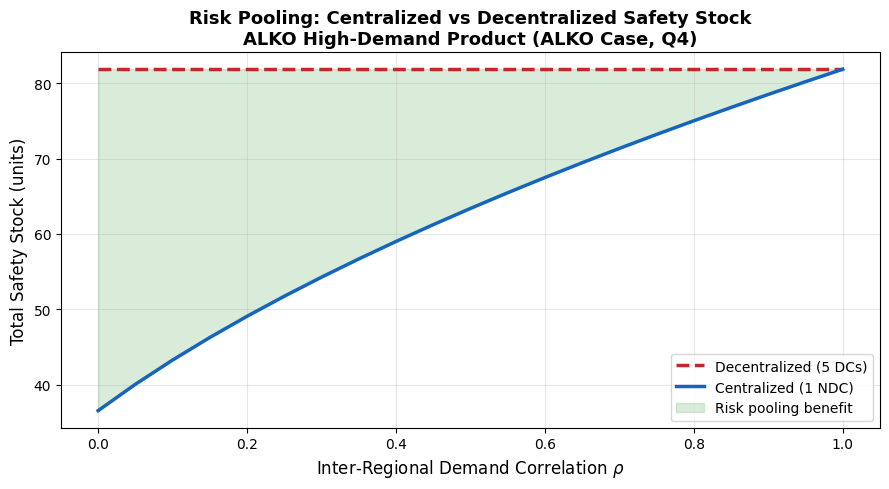

   rho    SS Centralized    SS Decentralized   Saving (units)
--------------------------------------------------------------
  0.00             36.60               81.83            45.23
  0.25             51.75               81.83            30.08
  0.50             63.39               81.83            18.44
  0.75             73.19               81.83             8.64
  1.00             81.83               81.83             0.00


In [ ]:
# Sensitivity of centralized vs decentralized safety stock
# All five regions have identical sigma_D = 3.0 units/day (High product).

K          = 5      # number of regions
sigma_D    = 3.0    # daily demand std dev per region (units/day)
rho_values = np.arange(0.0, 1.05, 0.05)

ss_centralized   = []
ss_decentralized = []

for rho in rho_values:
    # Decentralized: each DC carries its own safety stock independently
    sigma_TL_dec = np.sqrt(T + L) * sigma_D
    ss_dec_total = K * z * sigma_TL_dec

    # Centralized: pool demand across all 5 regions
    # Variance formula from the ALKO case
    var_central      = (K * sigma_D**2
                        + 2 * rho * (K * (K - 1) / 2) * sigma_D**2)
    sigma_central    = np.sqrt(var_central)
    sigma_TL_central = np.sqrt(T + L) * sigma_central
    ss_cen           = z * sigma_TL_central

    ss_centralized.append(ss_cen)
    ss_decentralized.append(ss_dec_total)

# Plot centralized vs decentralized safety stock across rho
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(rho_values, ss_decentralized, color='#C62828',
        linewidth=2.5, linestyle='--', label='Decentralized (5 DCs)')
ax.plot(rho_values, ss_centralized,   color='#1565C0',
        linewidth=2.5, label='Centralized (1 NDC)')
ax.fill_between(rho_values, ss_centralized, ss_decentralized,
                alpha=0.15, color='green', label='Risk pooling benefit')

ax.set_xlabel("Inter-Regional Demand Correlation $\\rho$", fontsize=12)
ax.set_ylabel("Total Safety Stock (units)", fontsize=12)
ax.set_title("Risk Pooling: Centralized vs Decentralized Safety Stock\n"
             "ALKO High-Demand Product (ALKO Case, Q4)",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary at key rho values
key_rhos = [0.0, 0.25, 0.5, 0.75, 1.0]
print(f"{'rho':>6}  {'SS Centralized':>16}  {'SS Decentralized':>18}  {'Saving (units)':>15}")
print("-" * 62)
for rho in key_rhos:
    idx    = int(round(rho / 0.05))
    saving = ss_decentralized[idx] - ss_centralized[idx]
    print(f"{rho:>6.2f}  {ss_centralized[idx]:>16.2f}  "
          f"{ss_decentralized[idx]:>18.2f}  {saving:>15.2f}")

### 4.6 Summary

In this section we performed three types of sensitivity analysis on the
ALKO inventory network:

1. **Capacity sensitivity**: reducing the capacity of one arc eventually
   makes the flow problem infeasible when it falls below the batch size Q. The $0.0000 shadow price confirms that in a star topology, capacity reductions never increase cost, they simply push toward infeasibility with no alternative routing to absorb the shortfall.

2. **Demand variability sensitivity**: safety stock and total annual cost
   grow linearly with $\sigma_D$, confirming the ROP policy formula. This shows that demand uncertainty is a key driver of inventory holding cost.

3. **Demand correlation sensitivity**: as inter-regional correlation $\rho$
   increases from 0 to 1, the risk pooling benefit of centralization shrinks
   to zero. This replicates the key managerial insight of ALKO Case Q4 that
   centralization is most valuable when regional demands are independent.

Together, these analyses answer the core question of sensitivity analysis:
*which parameters matter most, and by how much?* In Section 5 we use
NetworkX's graph-theoretic tools to identify the most critical nodes and
edges in the network from a structural perspective.

## Section 5: Network Vulnerability Analysis

### 5.1 Which Nodes and Arcs Matter Most?

So far we have analyzed sensitivity by changing cost and demand parameters.
A complementary question often is: *if a node or arc is removed
from the network entirely, how badly does the system break down?*

This is the core question of **network vulnerability analysis**, and NetworkX
has built-in tools to answer it. We use two measures:

**Degree centrality** measures how connected a node is relative to all other
nodes in the network. A node with high degree centrality touches many other
nodes where losing it disrupts many routes simultaneously.

$$C_D(i) = \frac{\text{deg}(i)}{|V| - 1}$$

where $\text{deg}(i)$ is the number of edges connected to node $i$ and
$|V|$ is the total number of nodes.

**Edge connectivity** measures the minimum number of arcs that would need
to be removed to disconnect two nodes entirely. A low edge connectivity
between two nodes means there are very few alternative routes between them, hence that the path is fragile.

$$\lambda(s, t) = \min \text{ number of arcs to remove to disconnect } s \text{ from } t$$

**Documentation:**
https://networkx.org/documentation/stable/reference/algorithms/centrality.html
https://networkx.org/documentation/stable/reference/algorithms/connectivity.html

### 5.2 Centrality of Supply Chain Nodes

We compute degree centrality for all nodes in the ALKO network. Because
the network is directed, NetworkX computes both **in-degree centrality**
(how many nodes ship into this node) and **out-degree centrality** (how
many nodes this node ships to).

In the ALKO star topology, the plant has the highest out-degree centrality
by construction as it connects to all five DCs. In a more complex network
with multiple plants, then centrality becomes a non-trivial diagnostic tool for identifying the nodes whose failure would cause the most disruption.

**AI Prompt:**
*"Using the alko_network graph already defined above, compute in-degree and
out-degree centrality for all nodes using NetworkX. Store the results in a
pandas DataFrame and print it sorted by out-degree centrality. Then draw
the network using node_positions and node_colors from before, scaling node
size proportionally to out-degree centrality."*

Node Centrality (sorted by out-degree):

           Node  In-Degree Centrality  Out-Degree Centrality
Plant_Cleveland                   0.0                    1.0
        DC_West                   0.2                    0.0
       DC_North                   0.2                    0.0
   DC_Southwest                   0.2                    0.0
   DC_Southeast                   0.2                    0.0
        DC_East                   0.2                    0.0


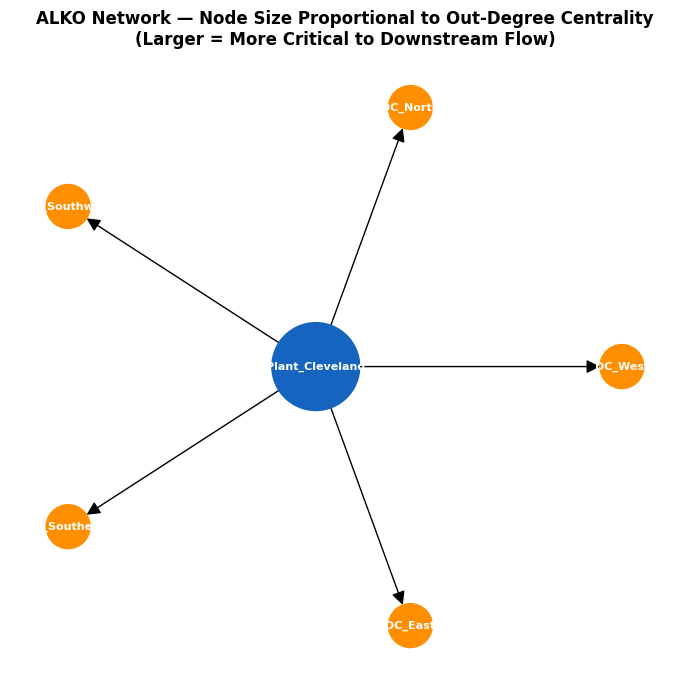

In [ ]:
# Compute degree centrality for all nodes in the ALKO network

in_centrality  = nx.in_degree_centrality(alko_network)
out_centrality = nx.out_degree_centrality(alko_network)

# Display as a summary table
centrality_df = pd.DataFrame({
    'Node':               list(in_centrality.keys()),
    'In-Degree Centrality':  [round(v, 3) for v in in_centrality.values()],
    'Out-Degree Centrality': [round(v, 3) for v in out_centrality.values()]
}).sort_values('Out-Degree Centrality', ascending=False)

print("Node Centrality (sorted by out-degree):\n")
print(centrality_df.to_string(index=False))

# Visualize: node size proportional to out-degree centrality
# Scale so that the plant (centrality=1.0) gets size 4000
# Leaf DCs (centrality=0.0) get size 1000
node_sizes = [
    1000 + 3000 * out_centrality[node]
    for node in alko_network.nodes()
]

fig, ax = plt.subplots(figsize=(7, 7))

nx.draw_networkx(
    alko_network,
    pos=node_positions,
    node_color=node_colors,
    node_size=node_sizes,
    font_size=8,
    font_weight='bold',
    font_color='white',
    arrows=True,
    arrowsize=20,
    ax=ax
)

ax.set_title("ALKO Network — Node Size Proportional to Out-Degree Centrality\n"
             "(Larger = More Critical to Downstream Flow)",
             fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

### 5.3 Node Failure Scenario: Removing a DC

The most direct vulnerability test is to simply remove a node and re-solve
the flow problem. This answers: *what happens to the network's ability to
meet demand if one DC goes offline?*

We remove DC_West from the network, simulating a warehouse closure, flood,
or fire, and check two things:
1. Can the remaining network still feasibly route flow to all other DCs?
2. How does the total replenishment cost change?

**AI Prompt:**
*"Using the flow_network and its existing demand and weight attributes,
create a copy with DC_West removed using nx.remove_node(). Then re-solve
nx.min_cost_flow() on the reduced network and print the new optimal flows
and total cost. Compare the cost to the baseline. Draw the reduced network
using the same layout, highlighting the missing node position in grey."*

Stress Test: DC_West Removed

Optimal flows to remaining DCs:
  Plant_Cleveland --> DC_North: 48.0 units
  Plant_Cleveland --> DC_Southwest: 48.0 units
  Plant_Cleveland --> DC_Southeast: 30.0 units
  Plant_Cleveland --> DC_East: 30.0 units

Baseline total cost (5 DCs): $20.52
Reduced total cost  (4 DCs): $14.04
Cost reduction from losing DC_West: $6.48

Note: DC_West demand of 72 units is now unmet.


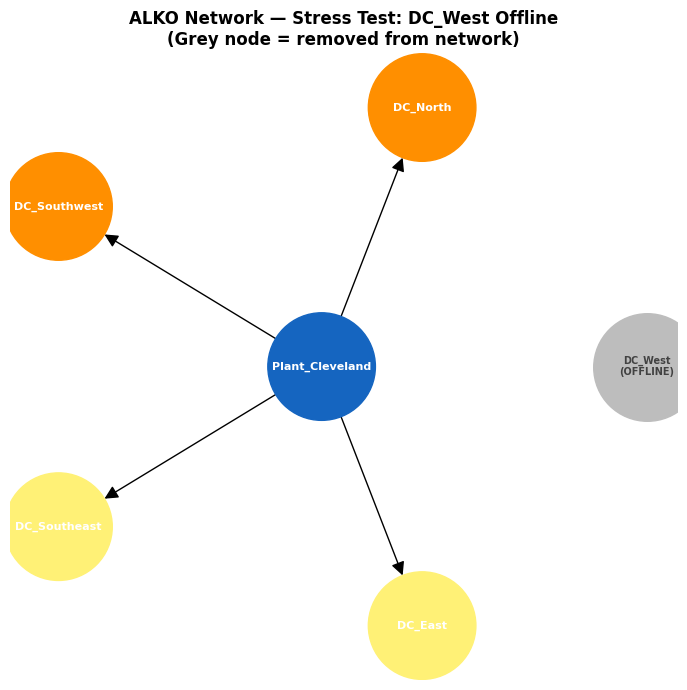

In [ ]:
# Stress test: remove DC_West entirely from the network.

# Baseline cost from Section 3 for comparison
baseline_cost = sum(
    flow_solution[u][v] * flow_network[u][v]['transport_cost']
    for u in flow_solution for v in flow_solution[u]
    if flow_solution[u][v] > 0
)

# Create a reduced network with DC_West removed
reduced_network = flow_network.copy()
reduced_network.remove_node('DC_West')

# Recompute plant supply: now only needs to cover 4 DCs
reduced_supply = sum(
    reduced_network.nodes[dc]['batch_size']
    for dc in dc_demand.keys()
    if dc != 'DC_West'
)
reduced_network.nodes['Plant_Cleveland']['demand'] = -reduced_supply

# Solve on the reduced network
try:
    reduced_solution = nx.min_cost_flow(reduced_network)
    reduced_cost = sum(
        reduced_solution[u][v] * reduced_network[u][v]['transport_cost']
        for u in reduced_solution for v in reduced_solution[u]
        if reduced_solution[u][v] > 0
    )

    print("Stress Test: DC_West Removed\n")
    print("Optimal flows to remaining DCs:")
    for u in reduced_solution:
        for v, flow in reduced_solution[u].items():
            if flow > 0:
                print(f"  {u} --> {v}: {flow:.1f} units")

    print(f"\nBaseline total cost (5 DCs): ${baseline_cost:.2f}")
    print(f"Reduced total cost  (4 DCs): ${reduced_cost:.2f}")
    print(f"Cost reduction from losing DC_West: ${baseline_cost - reduced_cost:.2f}")
    print(f"\nNote: DC_West demand of {batch_size_west:.0f} units is now unmet.")

except nx.NetworkXUnfeasible:
    print("Infeasible — the reduced network cannot meet remaining demand.")

# Visualize the reduced network, greying out DC_West position
fig, ax = plt.subplots(figsize=(7, 7))

# Draw the ghost of DC_West in grey to show what was lost
ax.scatter(*node_positions['DC_West'], s=6000,
           color='#BDBDBD', zorder=2)
ax.text(node_positions['DC_West'][0],
        node_positions['DC_West'][1],
        'DC_West\n(OFFLINE)', ha='center', va='center',
        fontsize=7, color='#424242', fontweight='bold')

# Draw remaining network
reduced_colors = [c for node, c in zip(alko_network.nodes(), node_colors)
                  if node != 'DC_West']
nx.draw_networkx(
    reduced_network,
    pos={k: v for k, v in node_positions.items() if k != 'DC_West'},
    node_color=reduced_colors,
    node_size=6000,
    font_size=8,
    font_weight='bold',
    font_color='white',
    arrows=True,
    arrowsize=20,
    ax=ax
)

ax.set_title("ALKO Network — Stress Test: DC_West Offline\n"
             "(Grey node = removed from network)",
             fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

### 5.4 Edge Connectivity: How Many Routes Can Fail?

Edge connectivity between two nodes tells us the minimum number of arcs
that would need to fail simultaneously to completely cut off the flow path
between them.

We compute edge connectivity between the plant and each DC. In the current
ALKO star topology, every plant-DC pair has connectivity of exactly 1,
there is only one direct arc between each pair, with no alternative routing.
This confirms that the ALKO decentralized network is structurally fragile where
any single arc failure cuts off one DC entirely.

**AI Prompt:**
*"Using the alko_network already defined above, compute edge connectivity
between Plant_Cleveland and each DC node using nx.edge_connectivity(G, source, target). Print the results in a table and explain what the values mean for supply chain resilience."*

In [ ]:
# Edge connectivity: minimum arcs to remove to disconnect plant_Cleveland from each DC.

print("Edge Connectivity: Plant_Cleveland → each DC\n")
print(f"{'DC':<20} {'Edge Connectivity':>20} {'Interpretation'}")
print("-" * 70)

for dc_name in dc_demand.keys():
    connectivity = nx.edge_connectivity(alko_network,
                                        'Plant_Cleveland', dc_name)
    if connectivity == 1:
        interpretation = "Single point of failure — no backup route"
    elif connectivity == 2:
        interpretation = "One backup route exists"
    else:
        interpretation = f"{connectivity} independent paths"

    print(f"{dc_name:<20} {connectivity:>20}     {interpretation}")

print("\nConclusion: All plant-DC pairs have connectivity = 1.")
print("The ALKO decentralized network has no redundancy.")
print("A single arc failure cuts off the affected DC entirely.")

Edge Connectivity: Plant_Cleveland → each DC

DC                      Edge Connectivity Interpretation
----------------------------------------------------------------------
DC_West                                 1     Single point of failure — no backup route
DC_North                                1     Single point of failure — no backup route
DC_Southwest                            1     Single point of failure — no backup route
DC_Southeast                            1     Single point of failure — no backup route
DC_East                                 1     Single point of failure — no backup route

Conclusion: All plant-DC pairs have connectivity = 1.
The ALKO decentralized network has no redundancy.
A single arc failure cuts off the affected DC entirely.


### 5.5 Summary and Tutorial Conclusion

In this section we used NetworkX's graph-theoretic tools to assess the
structural vulnerability of the ALKO inventory network:

- **Degree centrality** identified the Cleveland plant as the most critical
  node where its failure would simultaneously disrupt all five regional DCs
- **The DC removal stress test** showed that losing one DC reduces total
  cost (since less product is needed) but leaves that region's demand
  completely unmet, confirming that the network has no redundancy, a finding that directly motivates the mini-case.
- **Edge connectivity** confirmed that every plant-DC path has connectivity
  of 1, meaning a single arc failure is sufficient to cut off any DC

These structural findings complement the cost-based sensitivity analysis
from Section 4 where not only is the system sensitive to demand and capacity
parameters, but it is also architecturally fragile with no backup routes.

## Tutorial Summary

Across the five sections of this tutorial we have:

| Section | NetworkX Tool | Concept |
|---|---|---|
| 1 | DiGraph, add_node, add_edge | Supply chain networks |
| 2 | Node attributes, graph traversal | ALKO case, ROP policy |
| 3 | min_cost_flow | Transportation/transshipment LP |
| 4 | Parametric loops, graph copying | Sensitivity analysis, ALKO case scenarios |
| 5 | Centrality, edge_connectivity | Network resilience, stress testing |

The key insight connecting all five sections is that a supply chain is not
just a set of cost parameters, it is a **network structure** whose topology
directly determines which disruptions are costly, which are catastrophic,
and which parameters are worth investing in to improve.

**Bibliography**

- NetworkX documentation: https://networkx.org/documentation/stable/
- Chopra, S. & Meindl, P. *Supply Chain Management*, ALKO Inc. case, Ch. 12

### AI Usage Disclosure

I used Claude for this tutorial in the following ways:

**Code generation**: AI was prompted to generate initial versions of code cells, for NetworkX-specific syntax such as graph construction,
min_cost_flow setup, centrality computation, and visualization. Each prompt
is included above the code cells so the reader can see exactly
what was asked. All generated code was reviewed, tested, and modified when needed to ensure
correctness.

**Debugging**: AI was used to identify errors during development, such as
incorrect attribute references and NetworkX API misuse.

**Verification**: Every numerical result was cross-checked against the underlying ROP and EOQ
formulas to confirm correctness.

**Lessons learned**: I learnt that specifying exact variable names, parameter values, and formulas in my prompts prevented a lot of errors. Since AI does not know our exact course material, it would sometimes generate technically correct NetworkX code but with wrong parameter values or formulas until I explicitly told it which ones to use. I also found that asking for one code cell at a time worked much better than trying to get everything in one big prompt. This way the output was cleaner and easier to check for errors. Lastly, pasting error messages directly into the chat and asking what was wrong turned out to be a faster way to debug than googling the error.

# Mini Case - DropKicks

## Section 1: Business Story & Network Setup


DropKicks is a limited edition sneaker brand based in Los Angeles. Every few weeks, they releases a new drop, a small batch of highly anticipated shoes shipped from its central production facility to five regional fulfillment centers (FCs) across the US. Each FC serves its regional customer base through direct to consumer shipping.


Because demand for each drop is driven by hype, social media buzz, and resale market activity, it is highly uncertain. DropKicks must decide how many units to allocate to each FC before the drop, how much safety stock to hold to avoid stockouts, and which transport lanes are bottlenecks in the network.

The fulfillment network consists of:
- 1 central production facility in Los Angeles
- 5 regional fulfillment centers: West, South, Midwest, Northeast, and Southeast

This is a classic single-echelon inventory network where the production facility ships to FCs, which serve end customers directly. We use NetworkX to model the network, optimize the allocation, and perform sensitivity analysis on the optimal solution.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Inventory policy parameters
T   = 7      # review period (days) — weekly restocking before each drop
L   = 3      # shipping lead time (days)
CSL = 0.95   # cycle service level — DropKicks targets 95% in-stock rate
h   = 0.08   # holding cost ($/unit/day) — lower than ALKO since sneakers are durable, but hype fades so storage time is minimized
tr_in  = 0.12  # transport cost, facility -> FC ($/unit)
tr_out = 0.15  # transport cost, FC -> customer ($/unit)

# Demand parameters per FC (units/day during drop window)
# Generated to reflect regional sneaker culture and market size
# West and South are high-demand hype markets: Midwest and Northeast are medium; Southeast is lower volume.
fc_demand = {
    'FC_West':      {'tier': 'High',   'mean_demand': 15.0, 'demand_std': 6.0},
    'FC_South':     {'tier': 'High',   'mean_demand': 12.0, 'demand_std': 5.0},
    'FC_Midwest':   {'tier': 'Medium', 'mean_demand': 8.0,  'demand_std': 4.0},
    'FC_Northeast': {'tier': 'Medium', 'mean_demand': 10.0, 'demand_std': 4.0},
    'FC_Southeast': {'tier': 'Low',    'mean_demand': 6.0,  'demand_std': 3.0},
}

# Build the NetworkX directed graph
dropkicks = nx.DiGraph()

# Central production facility node (source — no demand, just supply)
dropkicks.add_node('Facility_LA', role='facility', mean_demand=0, demand_std=0)

# Regional FC nodes
for fc_name, attrs in fc_demand.items():
    dropkicks.add_node(fc_name, role='fulfillment_center', **attrs)

# Directed edges from facility to each FC
# capacity reflects refrigerated truck load limits per shipment
for fc_name in fc_demand.keys():
    dropkicks.add_edge('Facility_LA', fc_name,
                       transport_cost=tr_in,
                       capacity=150,
                       lead_time=L)

# Display structure
print("Nodes:")
for node, attrs in dropkicks.nodes(data=True):
    print(f"  {node}: {attrs}")

print("\nEdges:")
for u, v, attrs in dropkicks.edges(data=True):
    print(f"  {u} --> {v}: {attrs}")

Nodes:
  Facility_LA: {'role': 'facility', 'mean_demand': 0, 'demand_std': 0}
  FC_West: {'role': 'fulfillment_center', 'tier': 'High', 'mean_demand': 15.0, 'demand_std': 6.0}
  FC_South: {'role': 'fulfillment_center', 'tier': 'High', 'mean_demand': 12.0, 'demand_std': 5.0}
  FC_Midwest: {'role': 'fulfillment_center', 'tier': 'Medium', 'mean_demand': 8.0, 'demand_std': 4.0}
  FC_Northeast: {'role': 'fulfillment_center', 'tier': 'Medium', 'mean_demand': 10.0, 'demand_std': 4.0}
  FC_Southeast: {'role': 'fulfillment_center', 'tier': 'Low', 'mean_demand': 6.0, 'demand_std': 3.0}

Edges:
  Facility_LA --> FC_West: {'transport_cost': 0.12, 'capacity': 150, 'lead_time': 3}
  Facility_LA --> FC_South: {'transport_cost': 0.12, 'capacity': 150, 'lead_time': 3}
  Facility_LA --> FC_Midwest: {'transport_cost': 0.12, 'capacity': 150, 'lead_time': 3}
  Facility_LA --> FC_Northeast: {'transport_cost': 0.12, 'capacity': 150, 'lead_time': 3}
  Facility_LA --> FC_Southeast: {'transport_cost': 0.12, 'ca

The DropKicks fulfillment network has a star topology where one central facility is connected directly to each regional FC with no intermediate nodes. We visual, red for High, orange for Medium, and yellow for Low volume regions.

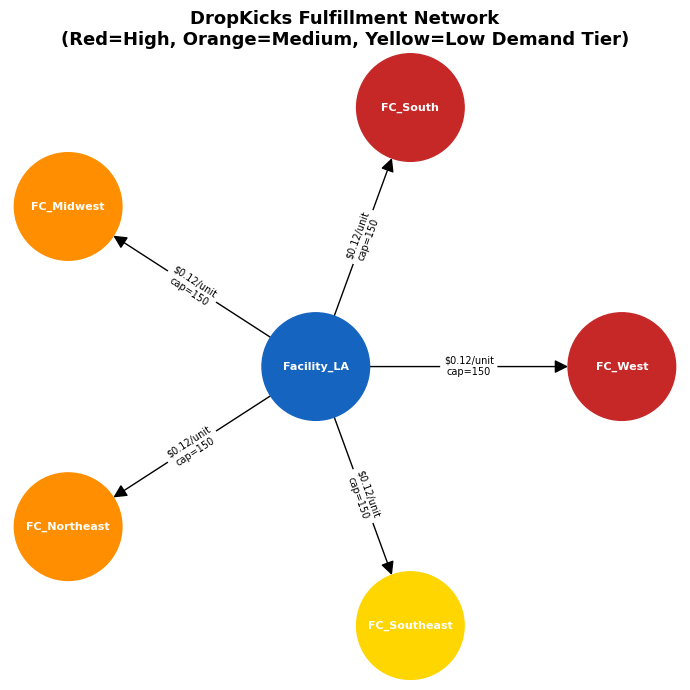

In [ ]:
# facility at center, FCs arranged in a circle
fc_nodes = list(fc_demand.keys())
n_fcs    = len(fc_nodes)

angles  = [2 * np.pi * i / n_fcs for i in range(n_fcs)]
radius  = 2.0

node_positions = {'Facility_LA': (0, 0)}
for fc_name, angle in zip(fc_nodes, angles):
    node_positions[fc_name] = (radius * np.cos(angle), radius * np.sin(angle))

# Color facility blue, FCs by demand tier (red=High, orange=Medium, yellow=Low)
tier_colors = {'High': '#C62828', 'Medium': '#FF8F00', 'Low': '#FFD600'}
node_colors = []
for node in dropkicks.nodes():
    if node == 'Facility_LA':
        node_colors.append('#1565C0')
    else:
        tier = dropkicks.nodes[node]['tier']
        node_colors.append(tier_colors[tier])

fig, ax = plt.subplots(figsize=(7, 7))

nx.draw_networkx(
    dropkicks,
    pos=node_positions,
    node_color=node_colors,
    node_size=6000,
    font_size=8,
    font_weight='bold',
    font_color='white',
    arrows=True,
    arrowsize=20,
    ax=ax
)

edge_labels = {
    (u, v): f"${d['transport_cost']}/unit\ncap={d['capacity']}"
    for u, v, d in dropkicks.edges(data=True)
}
nx.draw_networkx_edge_labels(dropkicks, pos=node_positions,
                              edge_labels=edge_labels, font_size=7, ax=ax)

ax.set_title("DropKicks Fulfillment Network\n(Red=High, Orange=Medium, Yellow=Low Demand Tier)",
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

Before optimizing the allocation, we compute the inventory policy parameters for each FC. Using the same ROP policy from the tutorial, we calculate the batch size (Q), safety stock (SS), reorder point (ROP), and expected total annual cost (ETAC) for each FC directly from its demand attributes. These parameters determine how many units each FC needs per review period and how much buffer stock to hold given demand uncertainty.

In [ ]:
# Compute ROP policy parameters for each FC node
tr_total = tr_in + tr_out   # total unit transport cost ($/unit)
z = stats.norm.ppf(CSL)     # z-score for CSL = 0.95 -> z = 1.645

for fc_name in fc_demand.keys():
    mu    = dropkicks.nodes[fc_name]['mean_demand']   # units/day
    sigma = dropkicks.nodes[fc_name]['demand_std']    # units/day

    # Batch size and cycle inventory
    batch_size = T * mu
    cycle_inv  = batch_size / 2

    # Demand variability over review + lead time window
    sigma_TL = np.sqrt(T + L) * sigma

    # Safety stock and reorder point
    safety_stock = z * sigma_TL
    rop          = (T + L) * mu + safety_stock

    # Expected total annual cost
    etac = 365 * ((safety_stock + cycle_inv) * h + mu * tr_total)

    # Store results back on the graph
    dropkicks.nodes[fc_name]['batch_size']   = round(batch_size, 2)
    dropkicks.nodes[fc_name]['cycle_inv']    = round(cycle_inv, 2)
    dropkicks.nodes[fc_name]['sigma_TL']     = round(sigma_TL, 2)
    dropkicks.nodes[fc_name]['safety_stock'] = round(safety_stock, 2)
    dropkicks.nodes[fc_name]['rop']          = round(rop, 2)
    dropkicks.nodes[fc_name]['etac']         = round(etac, 2)

# Display results
rows = []
for fc_name in fc_demand.keys():
    attrs = dropkicks.nodes[fc_name]
    rows.append({
        'FC':           fc_name,
        'Tier':         attrs['tier'],
        'Q (units)':    attrs['batch_size'],
        'Cycle Inv':    attrs['cycle_inv'],
        'Sigma T+L':    attrs['sigma_TL'],
        'Safety Stock': attrs['safety_stock'],
        'ROP':          attrs['rop'],
        'ETAC ($/yr)':  attrs['etac']
    })

results_df = pd.DataFrame(rows)
print(f"z-score for CSL={CSL}: {z:.4f}\n")
print(results_df.to_string(index=False))

z-score for CSL=0.95: 1.6449

          FC   Tier  Q (units)  Cycle Inv  Sigma T+L  Safety Stock    ROP  ETAC ($/yr)
     FC_West   High      105.0       52.5      18.97         31.21 181.21      3922.55
    FC_South   High       84.0       42.0      15.81         26.01 146.01      3168.42
  FC_Midwest Medium       56.0       28.0      12.65         20.81 100.81      2213.53
FC_Northeast Medium       70.0       35.0      12.65         20.81 120.81      2615.03
FC_Southeast    Low       42.0       21.0       9.49         15.60  75.60      1660.15


## Section 2: Optimal Drop Allocation

DropKicks must now decide how many units to ship to each FC before the drop. We formulate this as a minimum cost flow problem where the facility ships exactly each FC's batch size Q at minimum total transport cost, subject to lane capacity constraints.


To reflect realistic shipping constraints, the FC_West lane is capped at 120 units, tighter than the other lanes given higher West Coast port congestion. This creates a binding constraint that forces the solver to make an allocation decision.


In [ ]:
flow_network = dropkicks.copy()

# Compute total supply needed at the facility
total_supply = sum(
    flow_network.nodes[fc]['batch_size'] for fc in fc_demand.keys()
)

# Assign node demand attribute (required by nx.min_cost_flow)
# Facility supplies the total: negative demand = net supplier
flow_network.nodes['Facility_LA']['demand'] = -total_supply

# Each FC demands exactly its batch size Q
for fc_name in fc_demand.keys():
    q = flow_network.nodes[fc_name]['batch_size']
    flow_network.nodes[fc_name]['demand'] = q

# Assign edge attributes required by nx.min_cost_flow
for u, v in flow_network.edges():
    flow_network[u][v]['weight']   = flow_network[u][v]['transport_cost']
    flow_network[u][v]['capacity'] = 150

# Tighten FC_West lane to reflect West Coast port congestion
flow_network['Facility_LA']['FC_West']['capacity'] = 120

# Solve the minimum-cost flow problem
drop_solution = nx.min_cost_flow(flow_network)

# Display results
print("Optimal Drop Allocation (units shipped per lane):\n")
total_cost = 0
for u in drop_solution:
    for v, flow in drop_solution[u].items():
        if flow > 0:
            cost_per_unit = flow_network[u][v]['transport_cost']
            arc_cost      = flow * cost_per_unit
            total_cost   += arc_cost
            print(f"  {u} --> {v}: {flow:.0f} units  |  "
                  f"cost = {flow:.0f} x ${cost_per_unit} = ${arc_cost:.2f}")

print(f"\nTotal allocation cost (one drop): ${total_cost:.2f}")

Optimal Drop Allocation (units shipped per lane):

  Facility_LA --> FC_West: 105 units  |  cost = 105 x $0.12 = $12.60
  Facility_LA --> FC_South: 84 units  |  cost = 84 x $0.12 = $10.08
  Facility_LA --> FC_Midwest: 56 units  |  cost = 56 x $0.12 = $6.72
  Facility_LA --> FC_Northeast: 70 units  |  cost = 70 x $0.12 = $8.40
  Facility_LA --> FC_Southeast: 42 units  |  cost = 42 x $0.12 = $5.04

Total allocation cost (one drop): $42.84


We visualize the optimal allocation below, with edge width proportional to units shipped and labels showing flow against lane capacity.

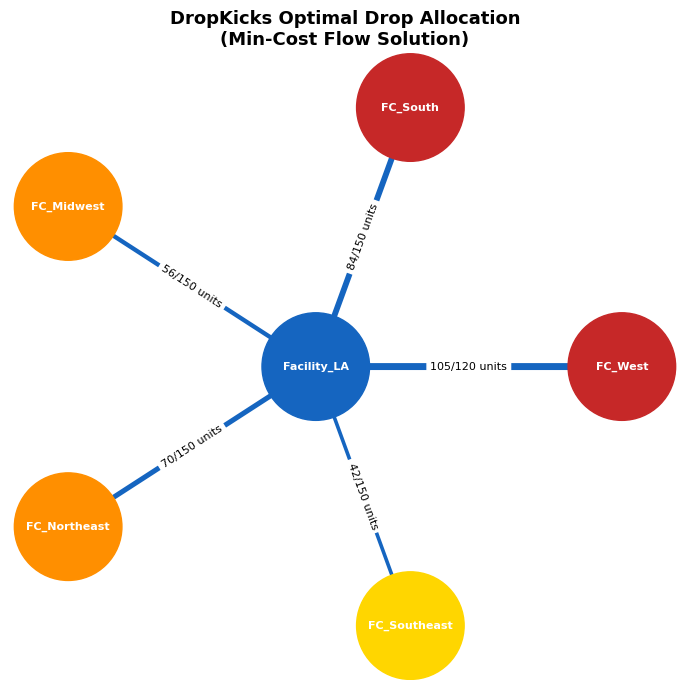

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

# Edge width proportional to flow
edge_flows  = [drop_solution[u][v] for u, v in flow_network.edges()]
max_flow    = max(edge_flows) if max(edge_flows) > 0 else 1
edge_widths = [1 + 4 * (f / max_flow) for f in edge_flows]

# Draw network
nx.draw_networkx_nodes(flow_network, pos=node_positions,
                       node_color=node_colors, node_size=6000, ax=ax)
nx.draw_networkx_labels(flow_network, pos=node_positions,
                        font_size=8, font_weight='bold',
                        font_color='white', ax=ax)
nx.draw_networkx_edges(flow_network, pos=node_positions,
                       width=edge_widths, arrows=True,
                       arrowsize=20, edge_color='#1565C0', ax=ax)

# Label edges with flow/capacity
flow_labels = {
    (u, v): f"{drop_solution[u][v]:.0f}/{flow_network[u][v]['capacity']} units"
    for u, v in flow_network.edges()
    if drop_solution[u][v] > 0
}
nx.draw_networkx_edge_labels(flow_network, pos=node_positions,
                              edge_labels=flow_labels, font_size=8, ax=ax)

ax.set_title("DropKicks Optimal Drop Allocation\n(Min-Cost Flow Solution)",
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

We compute arc utilization for each lane to identify which is closest to capacity, the bottleneck lane that sensitivity analysis will focus on.

Lane Utilization (sorted by bottleneck severity):

                      Lane  Flow  Capacity  Utilization
     Facility_LA → FC_West 105.0       120        0.875
    Facility_LA → FC_South  84.0       150        0.560
Facility_LA → FC_Northeast  70.0       150        0.467
  Facility_LA → FC_Midwest  56.0       150        0.373
Facility_LA → FC_Southeast  42.0       150        0.280


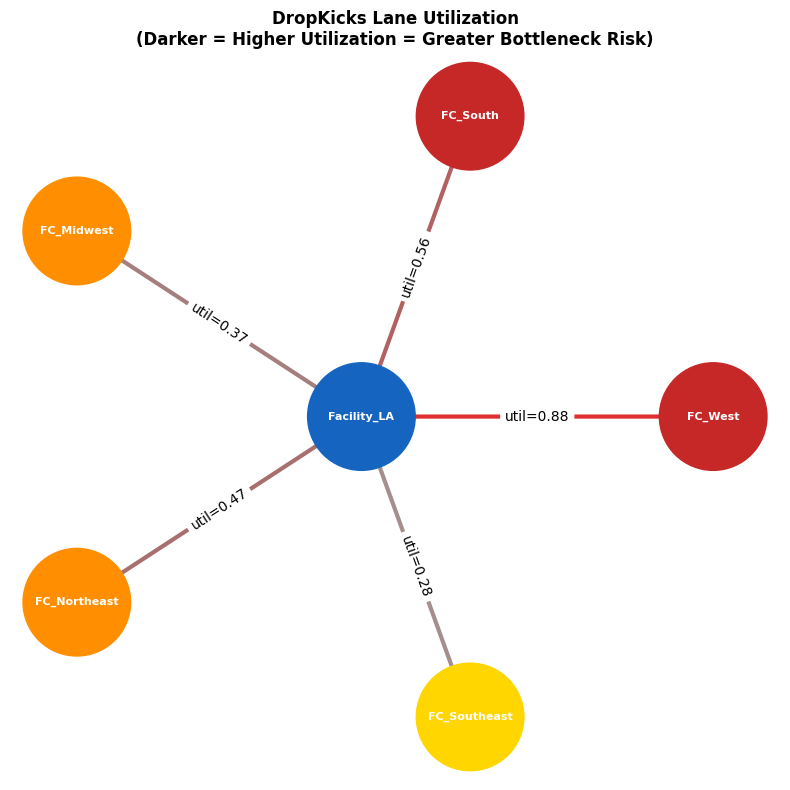

In [ ]:
# Compute arc utilization: flow / capacity
utilization_data = []
for u, v in flow_network.edges():
    f    = drop_solution[u][v]
    cap  = flow_network[u][v]['capacity']
    util = f / cap if cap > 0 else 0
    flow_network[u][v]['utilization'] = util
    utilization_data.append({
        'Lane':        f"{u} → {v}",
        'Flow':        round(f, 1),
        'Capacity':    cap,
        'Utilization': round(util, 3)
    })

util_df = pd.DataFrame(utilization_data).sort_values('Utilization', ascending=False)
print("Lane Utilization (sorted by bottleneck severity):\n")
print(util_df.to_string(index=False))

# Visualize utilization as edge color intensity
utilizations = [flow_network[u][v]['utilization'] for u, v in flow_network.edges()]
edge_colors  = [(util, 0.1, 0.1, 0.3 + 0.7 * util) for util in utilizations]

fig, ax = plt.subplots(figsize=(8, 8))

nx.draw_networkx_nodes(flow_network, pos=node_positions,
                       node_color=node_colors, node_size=6000, ax=ax)
nx.draw_networkx_labels(flow_network, pos=node_positions,
                        font_size=8, font_weight='bold',
                        font_color='white', ax=ax)
nx.draw_networkx_edges(flow_network, pos=node_positions,
                       edge_color=edge_colors, width=3,
                       arrows=True, arrowsize=20, ax=ax)

util_labels = {
    (u, v): f"util={flow_network[u][v]['utilization']:.2f}"
    for u, v in flow_network.edges()
}
nx.draw_networkx_edge_labels(flow_network, pos=node_positions,
                              edge_labels=util_labels, font_size=10, ax=ax)

ax.set_title("DropKicks Lane Utilization\n(Darker = Higher Utilization = Greater Bottleneck Risk)",
             fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

FC_West is the most constrained lane at 0.88 utilization, operating close to its capacity limit due to West Coast port congestion. All other lanes are well below capacity.

## Section 3: Sensitivity Analysis

The optimal allocation in Section 2 is based on a fixed set of parameters: lane capacities, demand levels, and demand variability. But in reality these parameters change where shipping lanes get congested, hype spikes unexpectedly, and demand becomes harder to predict. We now ask how much the optimal solution changes when these parameters shift.

- How does total allocation cost respond as the FC_West lane capacity tightens?
- How does safety stock grow as demand volatility increases?

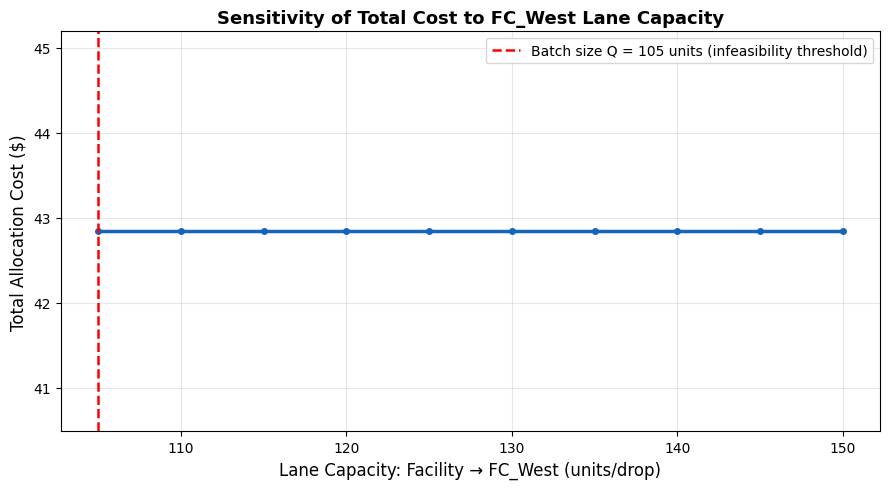

Minimum feasible capacity: 105 units
Approximate shadow price near threshold: $0.0000 per unit of capacity


In [ ]:
# Sensitivity analysis: vary FC_West lane capacity from 150 down to 50
capacity_values = list(range(150, 45, -5))
total_costs     = []
batch_size_west = dropkicks.nodes['FC_West']['batch_size']  # = 105 units

for cap in capacity_values:
    test_network = flow_network.copy()
    test_network['Facility_LA']['FC_West']['capacity'] = cap

    try:
        sol = nx.min_cost_flow(test_network)
        cost = sum(
            sol[u][v] * test_network[u][v]['transport_cost']
            for u in sol for v in sol[u]
            if sol[u][v] > 0
        )
        total_costs.append(cost)
    except nx.NetworkXUnfeasible:
        total_costs.append(np.nan)

# Plot sensitivity curve
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(capacity_values, total_costs,
        color='#1565C0', linewidth=2.5, marker='o', markersize=4)

ax.axvline(x=batch_size_west, color='red', linestyle='--', linewidth=1.8,
           label=f'Batch size Q = {batch_size_west:.0f} units (infeasibility threshold)')

ax.set_xlabel("Lane Capacity: Facility → FC_West (units/drop)", fontsize=12)
ax.set_ylabel("Total Allocation Cost ($)", fontsize=12)
ax.set_title("Sensitivity of Total Cost to FC_West Lane Capacity",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Shadow price approximation
feasible_df   = pd.DataFrame({'cap': capacity_values, 'cost': total_costs}).dropna()
feasible_df   = feasible_df.sort_values('cap').reset_index(drop=True)
delta_cost    = feasible_df['cost'].diff()
delta_cap     = feasible_df['cap'].diff()
shadow_approx = (delta_cost / delta_cap).dropna().iloc[-1]
print(f"Minimum feasible capacity: {feasible_df['cap'].min():.0f} units")
print(f"Approximate shadow price near threshold: ${abs(shadow_approx):.4f} per unit of capacity")

The flat cost curve confirms that in a star topology, reducing lane capacity does not increase cost, instead it simply pushes the system toward infeasibility at Q = 105 units. The $0.0000 shadow price means there are no alternative routes to absorb the shortfall, so any capacity below the batch size makes the drop allocation impossible for FC_West.

We now examine how safety stock requirements grow as demand volatility increases. For a hype driven brand like DropKicks, a viral moment can cause demand to spike unpredictably, making this a highly relevant sensetivity question for the business.

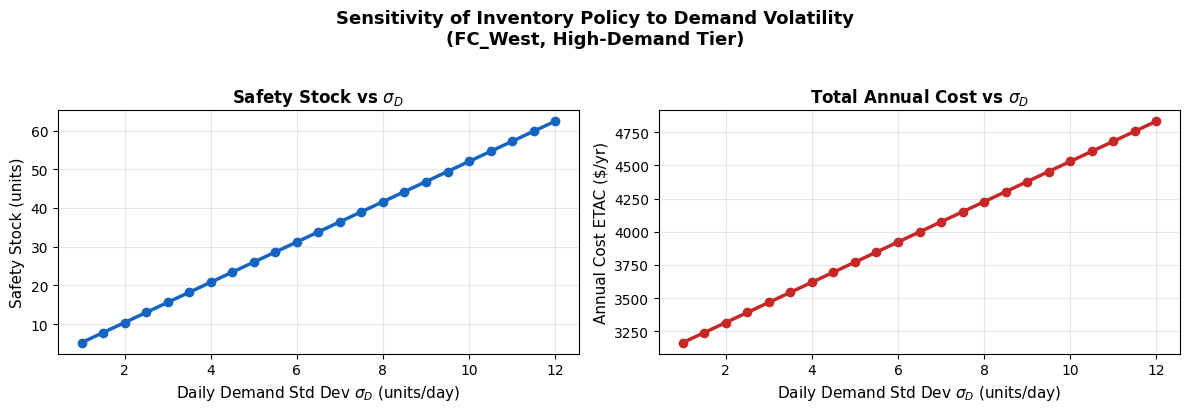

 sigma_D  Safety Stock  ETAC ($/yr)
     1.0          5.20      3163.13
     1.5          7.80      3239.07
     2.0         10.40      3315.02
     2.5         13.00      3390.96
     3.0         15.60      3466.90
     3.5         18.21      3542.84
     4.0         20.81      3618.78
     4.5         23.41      3694.72
     5.0         26.01      3770.67
     5.5         28.61      3846.61
     6.0         31.21      3922.55
     6.5         33.81      3998.49
     7.0         36.41      4074.43
     7.5         39.01      4150.37
     8.0         41.61      4226.32
     8.5         44.21      4302.26
     9.0         46.81      4378.20
     9.5         49.41      4454.14
    10.0         52.01      4530.08
    10.5         54.62      4606.02
    11.0         57.22      4681.97
    11.5         59.82      4757.91
    12.0         62.42      4833.85


In [ ]:
# Sensitivity of safety stock and ETAC to demand volatility
# We vary sigma_D for FC_West (highest volume FC) while holding mu fixed

sigma_values = np.arange(1.0, 12.5, 0.5)
mu_fixed     = dropkicks.nodes['FC_West']['mean_demand']  # 15.0 units/day

ss_results   = []
etac_results = []

for sigma in sigma_values:
    sigma_TL     = np.sqrt(T + L) * sigma
    safety_stock = z * sigma_TL
    batch_size   = T * mu_fixed
    cycle_inv    = batch_size / 2
    etac         = 365 * ((safety_stock + cycle_inv) * h + mu_fixed * tr_total)

    ss_results.append(safety_stock)
    etac_results.append(etac)

# Plot two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sigma_values, ss_results, color='#1565C0',
             linewidth=2.5, marker='o')
axes[0].set_xlabel("Daily Demand Std Dev $\\sigma_D$ (units/day)", fontsize=11)
axes[0].set_ylabel("Safety Stock (units)", fontsize=11)
axes[0].set_title("Safety Stock vs $\\sigma_D$", fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(sigma_values, etac_results, color='#C62828',
             linewidth=2.5, marker='o')
axes[1].set_xlabel("Daily Demand Std Dev $\\sigma_D$ (units/day)", fontsize=11)
axes[1].set_ylabel("Annual Cost ETAC ($/yr)", fontsize=11)
axes[1].set_title("Total Annual Cost vs $\\sigma_D$", fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle("Sensitivity of Inventory Policy to Demand Volatility\n"
             "(FC_West, High-Demand Tier)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary table
sens_df = pd.DataFrame({
    'sigma_D':      sigma_values,
    'Safety Stock': np.round(ss_results, 2),
    'ETAC ($/yr)':  np.round(etac_results, 2)
})
print(sens_df.to_string(index=False))

Safety stock grows linearly with demand volatility, confirming the ROP formula. For DropKicks, this means a viral moment that doubles $\sigma_D$​ from 6 to 12 units/day would nearly double the required safety stock at FC_West from 31 to 62 units, a direct hit to holding costs.


## Section 4: Stress Test

DropKicks' newest drop, the "Desert Flame" sneaker gets spotted on a celebrity at Coachella and immediately goes viral on Instagram. By the next morning, demand volatility across all FCs has tripled. We re-run the full allocation and inventory policy under this extreme scenario to test whether the network can still handle the drop.

In [ ]:
# Stress test: demand volatility triples across all FCs
# This simulates the Coachella viral moment overnight

stress_network = dropkicks.copy()

print("Stress Test: Demand Volatility Triples (Coachella Viral Moment)\n")
print(f"{'FC':<15} {'Normal SS':>10} {'Stress SS':>10} {'SS Increase':>12} {'Feasible?':>10}")
print("-" * 60)

stress_costs = 0
for fc_name in fc_demand.keys():
    mu        = dropkicks.nodes[fc_name]['mean_demand']
    sigma     = dropkicks.nodes[fc_name]['demand_std']

    # Triple the demand volatility
    sigma_stress = sigma * 3

    # Recompute inventory parameters under stress
    sigma_TL_stress     = np.sqrt(T + L) * sigma_stress
    safety_stock_stress = z * sigma_TL_stress
    batch_size          = dropkicks.nodes[fc_name]['batch_size']
    cycle_inv           = batch_size / 2
    etac_stress         = 365 * ((safety_stock_stress + cycle_inv) * h + mu * tr_total)

    # Store stress parameters back on graph
    stress_network.nodes[fc_name]['demand_std']   = sigma_stress
    stress_network.nodes[fc_name]['safety_stock'] = round(safety_stock_stress, 2)
    stress_network.nodes[fc_name]['etac']         = round(etac_stress, 2)

    normal_ss = dropkicks.nodes[fc_name]['safety_stock']
    print(f"{fc_name:<15} {normal_ss:>10.2f} {safety_stock_stress:>10.2f} "
          f"{safety_stock_stress - normal_ss:>12.2f} {'Yes':>10}")

# Re-run min-cost flow on stress network
# Demand quantities (batch sizes) are unchanged — only volatility changes
for fc_name in fc_demand.keys():
    stress_network.nodes[fc_name]['demand'] = stress_network.nodes[fc_name]['batch_size']
stress_network.nodes['Facility_LA']['demand'] = -total_supply

for u, v in stress_network.edges():
    stress_network[u][v]['weight']   = stress_network[u][v]['transport_cost']
    stress_network[u][v]['capacity'] = 150
stress_network['Facility_LA']['FC_West']['capacity'] = 120

try:
    stress_solution = nx.min_cost_flow(stress_network)
    stress_cost = sum(
        stress_solution[u][v] * stress_network[u][v]['transport_cost']
        for u in stress_solution for v in stress_solution[u]
        if stress_solution[u][v] > 0
    )
    print(f"\nAllocation still feasible under stress.")
    print(f"Total allocation cost (unchanged): ${stress_cost:.2f}")
except nx.NetworkXUnfeasible:
    print(f"\nAllocation INFEASIBLE under stress — network cannot meet demand.")

# Compare total safety stock
normal_ss_total = sum(dropkicks.nodes[fc]['safety_stock'] for fc in fc_demand.keys())
stress_ss_total = sum(stress_network.nodes[fc]['safety_stock'] for fc in fc_demand.keys())
print(f"\nTotal safety stock (normal):  {normal_ss_total:.2f} units")
print(f"Total safety stock (stress):  {stress_ss_total:.2f} units")
print(f"Increase:                     {stress_ss_total - normal_ss_total:.2f} units (+{((stress_ss_total/normal_ss_total)-1)*100:.0f}%)")

Stress Test: Demand Volatility Triples (Coachella Viral Moment)

FC               Normal SS  Stress SS  SS Increase  Feasible?
------------------------------------------------------------
FC_West              31.21      93.63        62.42        Yes
FC_South             26.01      78.02        52.01        Yes
FC_Midwest           20.81      62.42        41.61        Yes
FC_Northeast         20.81      62.42        41.61        Yes
FC_Southeast         15.60      46.81        31.21        Yes

Allocation still feasible under stress.
Total allocation cost (unchanged): $42.84

Total safety stock (normal):  114.44 units
Total safety stock (stress):  343.30 units
Increase:                     228.86 units (+200%)


The Coachella viral moment does not break the allocation, the network remains feasible and shipping costs are unchanged since batch sizes are fixed. However, the inventory picture is concerning where required safety stock triples across all FCs, jumping from 114 to 343 units network-wide which is a +200% increase.

 For DropKicks, this means the viral moment costs nothing in shipping but demands nearly three times the buffer inventory overnight. The FC_West lane, already the most constrained at 0.88 utilization, now carries the heaviest safety stock burden at 93 units. This stress test highlights the key vulnerability of a hype-driven brand, where shipping capacity is manageable, but inventory holding costs can spiral rapidly when demand volatility spikes.

## AI Usage Disclosure

I used Claude for this mini-case in the following ways:

**Code generation:** AI was prompted to generate initial versions of code cells for the DropKicks network setup, min-cost flow allocation, sensitivity analysis, and stress test. All generated code was reviewed, tested, and modified when needed to ensure it matched the mini-case story and produced correct results.

**Debugging:** AI was used to identify errors during development, such as incorrect node attribute references and flow network setup issues.

**Lessons learned:** For the mini-case I found it more effective to describe the business story first and then ask for code, rather than jumping straight to technical prompts. This kept the code grounded in the narrative. I also learned to specify parameter values explicitly in every prompt since AI would otherwise use generic placeholder values that did not match the mini-case setup.